# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [10]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos


In [11]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260107.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20251220.csv


## Main

### Visualize the cheeseboard maze task variables

In [12]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [4]:
dl.id, dl.ses_dir

('A', 'ses-07_date-20241211')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

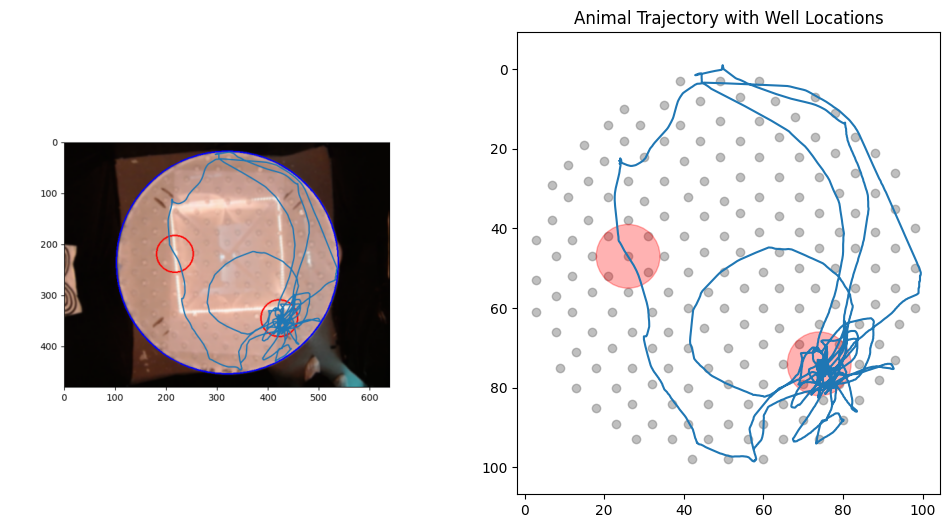

In [13]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [6]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [14]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


### Compute the time animal took to reach the trigger zone

In [15]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5141,63,BR,20251223,8,5,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5142,63,BR,20251223,8,6,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5143,63,BR,20251223,8,7,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5144,63,BR,20251223,8,8,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN


In [90]:
#  compute distance to first trigger entry for all trials
#  (optionally require first visit duration >= 2000 ms)

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata['dist_to_trigger'] = np.nan

R_TRIGGER = (10/1.2)

# --- SETTINGS you can comment/uncomment ---
REQUIRE_STAY_2S = False          # <- set False for "any entry"
MIN_DUR_MS = 2000               # duration threshold in ms (per your df_trig duration units)
# -----------------------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    pos = add_distance_travelled(position)
    if pos is None or len(pos) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    pos_ = add_dist_to_trigger(pos, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i+1)
        if df_trig is None or len(df_trig) == 0:
            continue
        df_trig['trigger_id'] = i + 1
        dfs.append(df_trig)

    # if never entered any reward zone at all, use full-trial distance
    if len(dfs) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = pos_['cum_dist'].iloc[-1]
        continue

    df_all = pd.concat(dfs, ignore_index=True).sort_values('t_enter').reset_index(drop=True)

    # ------------------------------------------------------------
    # OPTIONAL: require the FIRST visit where duration >= 2000 ms
    # ------------------------------------------------------------
    if REQUIRE_STAY_2S:
        df_use = df_all[df_all['duration'] >= MIN_DUR_MS].copy()
        # If no "stay" visits, decide what you want:
        # Option A: set distance to full-trial distance (like "never learned")
        if len(df_use) == 0:
            metadata.at[trial_id, 'dist_to_trigger'] = pos_['cum_dist'].iloc[-1]
            continue
        # Option B (alternative): set NaN instead
        # if len(df_use) == 0:
        #     metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        #     continue
    else:
        df_use = df_all

    # time of first qualifying entry to ANY trigger
    t_enter_first = df_use.iloc[0]['t_enter']

    # distance travelled up to that time (last sample with t <= t_enter_first)
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    dist_to_trigger = 0.0 if len(idxs) == 0 else pos_['cum_dist'].iloc[idxs[-1]]

    metadata.at[trial_id, 'dist_to_trigger'] = dist_to_trigger

metadata[['sub','ses','trial_type','trial_type_day','dist_to_trigger']].head()

 15%|█▌        | 707/4611 [00:07<00:36, 106.86it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1182/4611 [00:11<00:30, 111.27it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2618/4611 [00:23<00:11, 168.33it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:39<00:00, 117.85it/s]


,sub,ses,trial_type,trial_type_day,dist_to_trigger
0,1,1,H,1,21.004940
1,1,1,H,1,121.123247
2,1,1,H,1,39.502281
3,1,1,H,1,7.878806
4,1,1,H,1,132.454986


ChR2 animals plotted: 10
eYFP_ChR2 animals plotted: 5


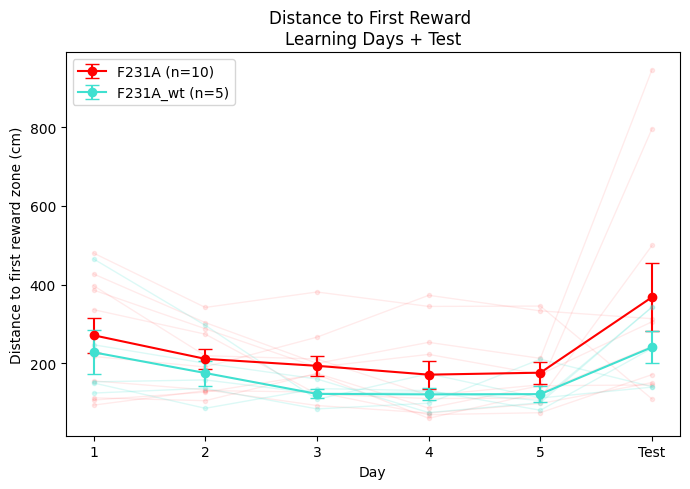

In [91]:
# ============================================================
# Distance to first reward-zone entry
# Plot ChR2 vs eYFP_ChR2
# Metric: dist_to_trigger
# ============================================================

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
   # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['dist_to_trigger'].notna())
].copy()

# Create "plot_day": learning = 1–5, test = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → day 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials after learning
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # L1–L5 + Test

# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['dist_to_trigger'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
#meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
#meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5

# ---- ChR2 (red) ----
if mat_ChR2 is not None:
    for row in mat_ChR2:
        plt.plot(
            x_vals, row,
            '-o', color='red',
            alpha=0.08, linewidth=1, markersize=3,
            label='_nolegend_'
        )

    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(
        x_vals, mean_c, yerr=sem_c,
        fmt='-o', color='red', capsize=5,
      #  label=f'ChR2 (n={len(subs_ChR2)})'
        label=f'F231A (n={len(subs_ChR2)})'
    )

# ---- eYFP (turquoise) ----
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(
            x_vals, row,
            '-o', color='turquoise',
            alpha=0.18, linewidth=1, markersize=3,
            label='_nolegend_'
        )

    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(
        x_vals, mean_y, yerr=sem_y,
        fmt='-o', color='turquoise', capsize=5,
      #  label=f'eYFP_ChR2 (n={len(subs_eYFP)})'
        label=f'F231A_wt (n={len(subs_eYFP)})'
    )

plt.xlabel('Day')
plt.ylabel('Distance to first reward zone (cm)')
plt.title('Distance to First Reward \nLearning Days + Test')
#(≥2 s stay)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend()
plt.tight_layout()
plt.show()

In [92]:
# Compute mean speed per trial

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata['mean_speed'] = np.nan  # cm/s

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)

    # remove zeros / NaNs if needed
    speeds = pos['speed'].values
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        continue

    metadata.at[trial_id, 'mean_speed'] = np.nanmean(speeds)

metadata[['sub','ses','trial_type','trial_type_day','mean_speed']].head()

 15%|█▌        | 710/4611 [00:04<00:24, 156.97it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1196/4611 [00:07<00:19, 171.05it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2621/4611 [00:15<00:06, 285.44it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:25<00:00, 179.83it/s]


,sub,ses,trial_type,trial_type_day,mean_speed
0,1,1,H,1,13.183545
1,1,1,H,1,9.790948
2,1,1,H,1,9.168459
3,1,1,H,1,9.678405
4,1,1,H,1,10.652230


ChR2 animals plotted: 10
eYFP_ChR2 animals plotted: 5


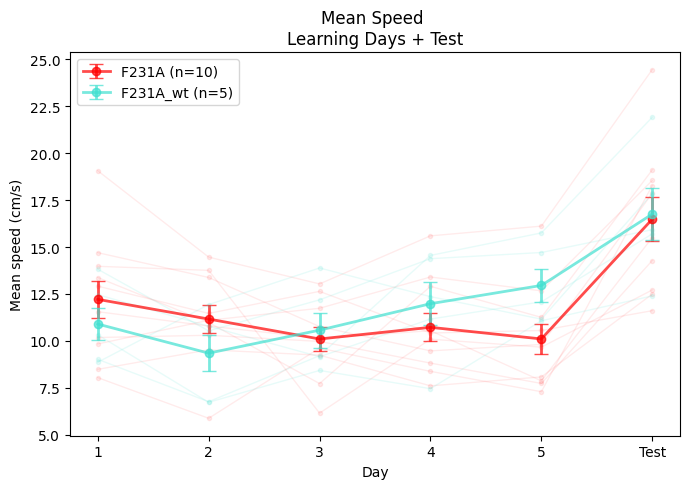

In [97]:


# ---------------------------------------------------------------------
# 1) Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
  #  (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
  #  (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &  
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
             ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['mean_speed'].notna())
].copy()

# Create plot_day: learning = 1–5, test = 6 (assigned per animal)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix (mean_speed), require complete days
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, require_complete=True):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['mean_speed'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

#meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2'].copy()
#meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2'].copy()
#meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp'].copy()          

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A'].copy()
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt'].copy()

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2, require_complete=True)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP, require_complete=True)
#mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp,   require_complete=True)  

print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
#print("Hp animals plotted:", len(subs_Hp))

# ---------------------------------------------------------------------
# 3) Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5

def plot_group(mat, subs, color, label,
               alpha_mean=0.7,
               alpha_ind=0.1,     # faded traces
               show_individual=True):

    if mat is None or len(subs) == 0:
        return

    # ---- individual animals ----
    if show_individual:
        for row in mat:
            plt.plot(
                x_vals, row,
                '-o',
                color=color,
                alpha=alpha_ind,
                linewidth=1,
                markersize=3,
                label='_nolegend_'   # hide from legend
            )

    # ---- mean ± SEM ----
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        alpha=alpha_mean,     # <-- THIS is what you want
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )

# ---- Plot groups (mean curves only) ----
plot_group(mat_ChR2, subs_ChR2,
           color='red',
         #  label='ChR2',
           label='F231A',
           alpha_mean=0.7,
           alpha_ind=0.08,     # ChR2 trace fadedness
           show_individual=True)


plot_group(mat_eYFP, subs_eYFP,
           color='turquoise',
           #  label='eYFP_ChR2',
           label='F231A_wt',
           alpha_mean=0.7,
           alpha_ind=0.12,     
           show_individual=True)


#plot_group(mat_Hp, subs_Hp,
#           color='#2ca02c',         # green
#           label='Hp',
#           alpha_mean=1)          # less faded

plt.xlabel('Day')
plt.ylabel('Mean speed (cm/s)')
plt.title('Mean Speed \nLearning Days + Test')

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend()
plt.tight_layout()
plt.show()

Animals included (learning trials only):
  ChR2: 12
  eYFP: 5


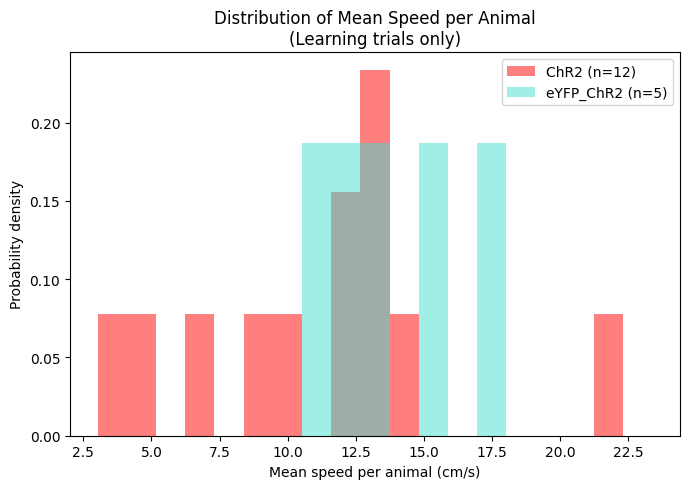

In [87]:
# Distribution of Mean Speed per Animal
# 1) Restrict to LEARNING trials only
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['mean_speed'].notna())
].copy()

# ------------------------------------------------------------
# 2) Per-animal mean speed (average across learning trials)
# ------------------------------------------------------------
meta_animal = (
    meta_L
    .groupby(['genotype', 'sub'])['mean_speed']
    .mean()
    .reset_index()
)

speeds_ChR2 = meta_animal.loc[
    meta_animal['genotype'] == 'ChR2', 'mean_speed'
].values

speeds_eYFP = meta_animal.loc[
    meta_animal['genotype'] == 'eYFP_ChR2', 'mean_speed'
].values

print("Animals included (learning trials only):")
print("  ChR2:", len(speeds_ChR2))
print("  eYFP:", len(speeds_eYFP))

# ------------------------------------------------------------
# 3) Plot histogram
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

bins = np.linspace(
    np.nanmin(meta_animal['mean_speed']),
    np.nanmax(meta_animal['mean_speed']),
    20
)

plt.hist(
    speeds_ChR2,
    bins=bins,
    color='red',
    alpha=0.5,
    density=True,
    label=f'ChR2 (n={len(speeds_ChR2)})'
)

plt.hist(
    speeds_eYFP,
    bins=bins,
    color='turquoise',
    alpha=0.5,
    density=True,
    label=f'eYFP_ChR2 (n={len(speeds_eYFP)})'
)

plt.xlabel('Mean speed per animal (cm/s)')
plt.ylabel('Probability density')
plt.title('Distribution of Mean Speed per Animal\n(Learning trials only)')
plt.legend()
plt.tight_layout()
plt.show()

Speed samples per day (should differ):
  Day 1: 456899 samples
  Day 2: 443936 samples
  Day 3: 466650 samples
  Day 4: 437309 samples
  Day 5: 423805 samples


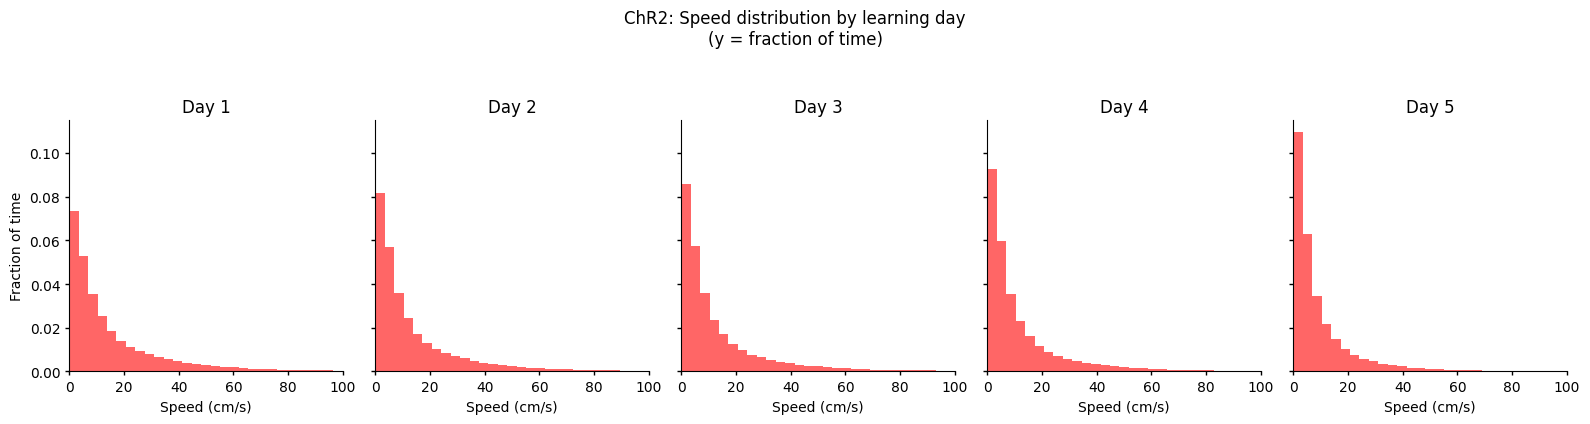

In [ ]:
# =============================================================
# Speed distribution by learning day
# =============================================================

# ----------------------------
# SETTINGS
# ----------------------------
days = [1, 2, 3, 4, 5]

# ----------------------------
# 1) Filter trial table (ChR2 learning only)
# ----------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin(days))
].copy()

# IMPORTANT: keep the original integer row index so we can do metadata.iloc[idx]
trial_indices = meta_L.index.to_numpy()

# ----------------------------
# 2) Collect SPEED SAMPLES per day (fraction of time)
# ----------------------------
speed_by_day = {d: [] for d in days}

for idx in trial_indices:
    day = int(metadata.loc[idx, 'trial_type_day'])

    dl = DataLoader(metadata.loc[idx])  # <-- use the same object style you already use
    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)  # must create pos['speed']
    speeds = pos['speed'].values
    speeds = speeds[np.isfinite(speeds)]
    speeds = speeds[speeds > 0]   # optional: remove 0 speed samples

    if len(speeds) == 0:
        continue

    speed_by_day[day].append(speeds)

# concatenate per day
for d in days:
    speed_by_day[d] = np.concatenate(speed_by_day[d]) if len(speed_by_day[d]) > 0 else np.array([])

# DEBUG: confirm they differ
print("Speed samples per day (should differ):")
for d in days:
    print(f"  Day {d}: {len(speed_by_day[d])} samples")

# ----------------------------
# 3) Plot: histogram per day
#    y = fraction of time (density=True)
# ----------------------------
all_speeds = np.concatenate([speed_by_day[d] for d in days if len(speed_by_day[d]) > 0])
bins = np.linspace(0, 100, 30)

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

for ax, d in zip(axes, days):
    speeds = speed_by_day[d]

    ax.hist(
        speeds,
        bins=bins,
        density=True,   # fraction of time
        color='red',
        alpha=0.6,
        edgecolor='none'
    )

    ax.set_xlim(0, 100)          # ✅ force x-axis range
    ax.set_title(f'Day {d}')
    ax.set_xlabel('Speed (cm/s)')

    if d == 1:
        ax.set_ylabel('Fraction of time')

    # Nature-style axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)

fig.suptitle(
    'ChR2: Speed distribution by learning day\n'
    '(y = fraction of time)',
    y=1.05,
    fontsize=12
)

plt.tight_layout()
plt.show()

In [99]:
# ------------------------------------------------------------
# Compute mean speed up to FIRST reward-zone arrival
# (optionally require ≥2000 ms stay)
# ------------------------------------------------------------

metadata['mean_speed_to_trigger'] = np.nan

R_TRIGGER = (10 / 1.2)

# ----------------------------
# TOGGLE THIS
# ----------------------------
USE_MIN_DURATION = False      # set False to ignore duration
MIN_DURATION_MS = 2000       # ms
# ----------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    # add speed + distance info
    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    # collect all trigger visits
    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    # never entered any reward zone
    if len(dfs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue

    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    # ----------------------------
    # OPTIONAL: require ≥2000 ms stay
    # ----------------------------
    if USE_MIN_DURATION:
        df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

    if len(df_all) == 0:
        # never satisfied criterion → use full trial
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue
    # ----------------------------

    # first qualifying entry time
    t_enter_first = df_all.iloc[0]['t_enter']

    # speed up to that time
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    if len(idxs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = 0.0
        continue

    metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(
        pos_['speed'].iloc[idxs]
    )

 15%|█▌        | 704/4611 [00:06<00:35, 110.83it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1184/4611 [00:10<00:28, 121.13it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2617/4611 [00:21<00:11, 178.52it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:36<00:00, 124.88it/s]


Animals plotted:
  ChR2: 10
  eYFP: 5


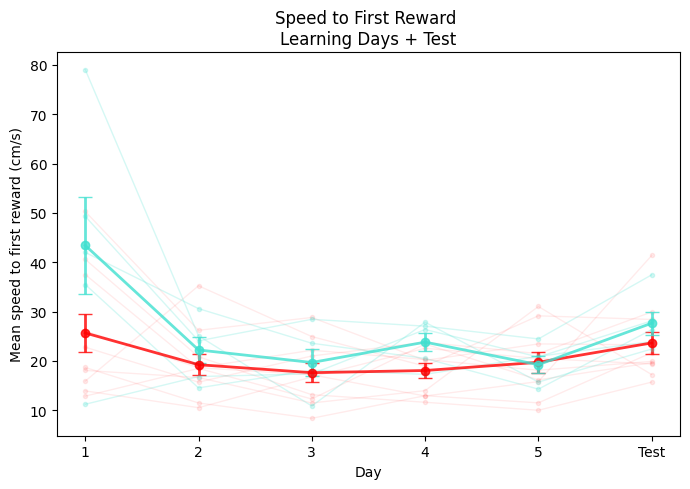

In [100]:
# Speed to first reward zone entry
# Plot ChR2 vs eYFP_ChR2 vs Hp

# ------------------------------------------------------------
# 1) Filter metadata 
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
   # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
        ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['mean_speed_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Assign plot_day (L = 1–5, first T after learning = 6)
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan
meta_LT.loc[meta_LT['trial_type'] == 'L', 'plot_day'] = meta_LT['trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 3) Subject × day matrix
# ------------------------------------------------------------
def build_matrix(meta_g):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]
        mean_by_day = ms.groupby('plot_day')['mean_speed_to_trigger'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs


#meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
#meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
#meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_matrix(meta_eYFP)
#mat_Hp,   subs_Hp   = build_matrix(meta_Hp)

print("Animals plotted:")
print("  ChR2:", len(subs_ChR2))
print("  eYFP:", len(subs_eYFP))
#print("  Hp  :", len(subs_Hp))

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------

SHOW_INDIVIDUALS = True   # <<< TOGGLE THIS (True / False)

plt.figure(figsize=(7, 5))
x = plot_days - 1

def plot_group(mat, color, label, alpha_mean=0.7, alpha_ind=0.15):
    if mat is None or mat.shape[0] == 0:
        return

    # ----------------------------
    # individual animals (optional)
    # ----------------------------
    if SHOW_INDIVIDUALS:
        for row in mat:
            plt.plot(
                x, row, '-o',
                color=color,
                alpha=alpha_ind,
                linewidth=1,
                markersize=3,
                label='_nolegend_'
            )

    # ----------------------------
    # mean ± SEM
    # ----------------------------
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        alpha=alpha_mean,
        linewidth=2,
        capsize=5,
        label=f'{label} (n={mat.shape[0]})'
    )


plot_group(mat_ChR2, 'red',        'ChR2',       alpha_mean=0.8, alpha_ind=0.08)
plot_group(mat_eYFP, 'turquoise',  'eYFP_ChR2',  alpha_mean=0.8, alpha_ind=0.22)
#plot_group(mat_Hp,   '#2ca02c',    'Hp',         alpha_mean=0.8)

plt.xlabel('Day')
plt.ylabel('Mean speed to first reward (cm/s)')
plt.title('Speed to First Reward \nLearning Days + Test')
#(≥2 s stay)
plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'])
#plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [56]:
# plot time to arrive in reward zone

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)  # <-- only recruit the trials if usable = 1

# Define a column in metadata to save the time to trigger zone
metadata['t_to_trigger'] = 0
# Define another column to save if animal ever learned to stay at the trigger zone
metadata['learned'] = False

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None:
        continue
    cheeseboardMap = util.load_cheeseboard_map()
    triggerLoc = dl.get_data('triggerLoc')

    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti = i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    # Find time to trigger
    df_all_triggers_long = df_all_triggers[df_all_triggers['duration']>=2000]
    # decide if we want visits with duration > 2000 ms (2 s) only or all visits
     #df_all_triggers_long = df_all_triggers
    
    if len(df_all_triggers_long) == 0:
        # If animal never spent more than dt in the trigger zone, time to trigger is equal to the duration of the trial
        t_to_trigger = position_.iloc[-1]['t']
        
    else:
        t_to_trigger = df_all_triggers_long.iloc[0]['t_enter']
        metadata.at[trial_id, 'learned'] = True
    


    metadata.at[trial_id, 't_to_trigger'] = t_to_trigger





 15%|█▌        | 708/4611 [00:06<00:36, 107.19it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1178/4611 [00:11<00:30, 111.16it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2615/4611 [00:23<00:12, 158.75it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:40<00:00, 114.09it/s]


In [238]:
for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    try:
        position = dl.get_data('position')
    except KeyError as e:
        print("Failed trial:", trial_id, "sub:", dl.id, "ses:", dl.ses_dir)
        pos_raw = util.load_data(dl.generate_filepath('position', 'derivatives', 'behav', 'csv'))
        print("position raw index head:", pos_raw.index[:10])
        print("position raw shape:", pos_raw.shape)
        raise

 17%|█▋        | 709/4106 [00:04<00:23, 145.54it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 29%|██▉       | 1188/4106 [00:08<00:19, 146.45it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 63%|██████▎   | 2602/4106 [00:16<00:05, 280.17it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


 94%|█████████▍| 3862/4106 [00:22<00:01, 170.51it/s]


Failed trial: 3862 sub: BF ses: ses-01_date-20251122
position raw index head: RangeIndex(start=0, stop=10, step=1)
position raw shape: (121, 17)


KeyError: 0

([<matplotlib.axis.XTick at 0x12224e210>,
 [Text(0, 0, 'Day 1'),
  Text(1, 0, 'Day 2'),
  Text(2, 0, 'Day 3'),
  Text(3, 0, 'Day 4'),
  Text(4, 0, 'Day 5')])

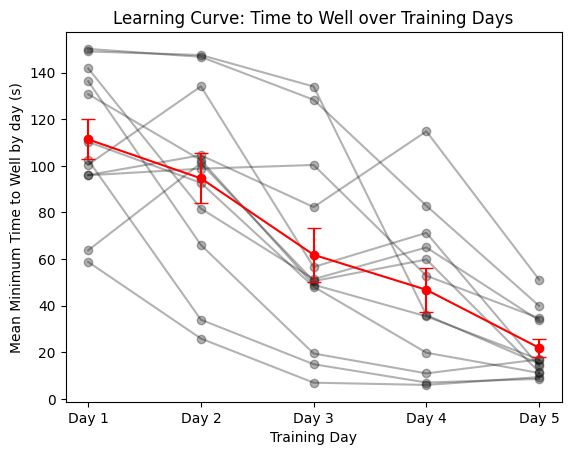

In [50]:
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
    ].reset_index(drop=True)

# 

performance_mat = []
for sub in metadata_L['sub'].unique():
    metadata_L_A = metadata_L[metadata_L['sub'] == sub]#.reset_index(drop=True)
    mean_performance_by_day = metadata_L_A.groupby('trial_type_day')['t_to_trigger'].mean().values
    if len(mean_performance_by_day)!=5:
        continue
    performance_mat.append(mean_performance_by_day)
    plt.plot(range(0,5), mean_performance_by_day/1000, '-o',color='k', alpha=0.3)

performance_mat = np.vstack(performance_mat)
# Get the mean and standard error across subjects
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])
plt.errorbar(range(0,5), mean_performance/1000, yerr=sem_performance/1000, fmt='-o', color='r', capsize=5)
plt.xlabel('Training Day')
plt.ylabel('Mean Minimum Time to Well by day (s)')
plt.title('Learning Curve: Time to Well over Training Days')

plt.xticks(range(0,5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])

ChR2 animals in dataset: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in dataset: 5
eYFP_ChR2 animals plotted: 5


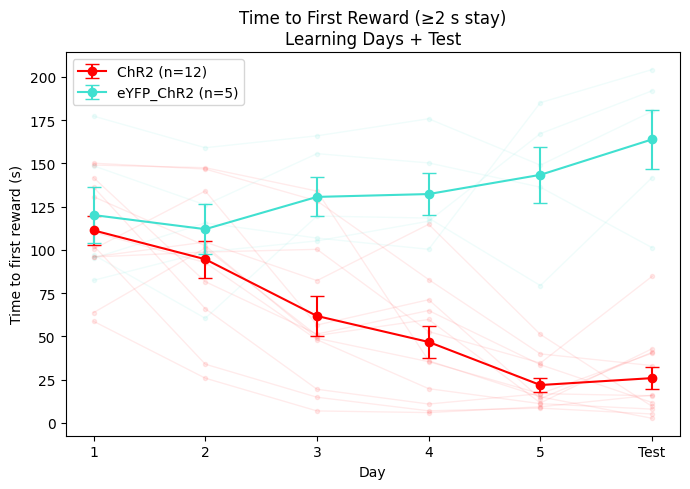

In [32]:
# time to arrive at new reward ChR2 vs YFP and stayed there for at least 2 sec

# Plot ChR2 & eYFP_ChR2 learning trials + first test day by session
# Metric: time to first reward (t_to_trigger), in seconds

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create "plot_day": learning = 1–5, test = 6 (assigned later)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # this animal has no test day

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect 6 days: L1–L5 + Test
plot_days = np.arange(1, 7)

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean time to first reward per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in dataset:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in dataset:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ---- ChR2 (red) ----
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(x_vals, row / 1000, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')

    # mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(
        x_vals, mean_c / 1000, yerr=sem_c / 1000,
        fmt='-o', color='red', capsize=5,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# ---- eYFP (turquoise) ----
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(x_vals, row / 1000, '-o', color='turquoise', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')

    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(
        x_vals, mean_y / 1000, yerr=sem_y / 1000,
        fmt='-o', color='turquoise', capsize=5,
        label=f'eYFP_ChR2 (n={len(subs_eYFP)})'
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay)\nLearning Days + Test')
#(≥2 s stay)
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()



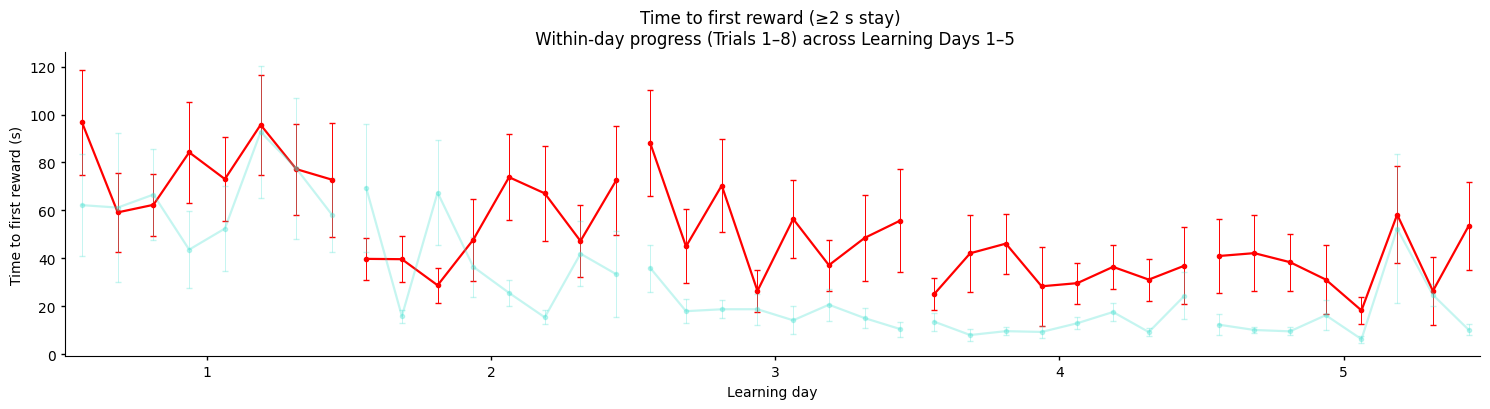

In [58]:

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    #(metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
             ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if np.all(np.isnan(vals)):
            continue
        rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,        # <-- add this
            linewidth=1.6,
            elinewidth=0.7,
            capsize=2,
            markersize=3
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# Split by genotype
meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()

# Wider figure so Day 5 curve isn't clipped
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red', alpha=1.0)
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)  # <-- more faded

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# Centered day ticks
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure Day 5 curve fully visible

ax.set_xlim(1.0, 5.98)

ax.set_title('Time to first reward (≥2 s stay) \n Within-day progress (Trials 1–8) across Learning Days 1–5', fontsize=12)
#(≥2 s stay)

style_nature(ax)

plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5
  Hp: 7


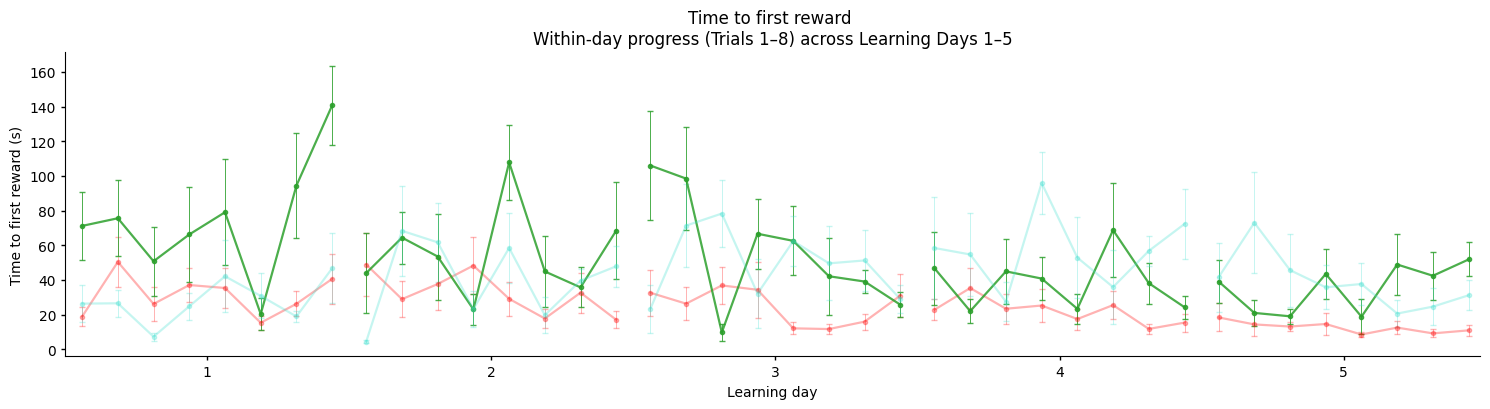

In [ ]:
# Plot ChR2 vs eYFP_ChR2 vs Hp learning trials

# ------------------------------------------------------------
# 1) Filter: usable animals, include 3 genotypes, L only, days 1–5
#    exclude short_duration==1 and exclude missing t_to_trigger (==0)
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    # fallback: infer by order within (sub, ses)
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        # keep subject if they have at least 1 trial that day
        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
#    (group mean ± SEM; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points inside each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0  # ms -> s
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            elinewidth=0.7,   # thinner SEM bars
            capsize=2,
            markersize=3
        )

# ------------------------------------------------------------
# 5) Nature-style axes (no top/right box)
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Split by genotype (3 groups)
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
print("  Hp:", meta_Hp['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot (wider; centered day ticks; extra room for day 5 curve)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red',       alpha=0.3)
plot_within_day_curves(ax, meta_Hp,   color='#2ca02c',   alpha=0.85)  # Hp in green
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)  # control faded

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# Center x tick labels under each day's curve (middle of the curve)
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Tighten left space + ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Time to first reward \n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

#(≥2 s stay)

style_nature(ax)

plt.tight_layout()
plt.show()

Animals included (n):
  ChR2 long (L, short_duration=0): 12
  eYFP_ChR2 (L): 5
  ChR2 short (SL, short_duration=1): 4


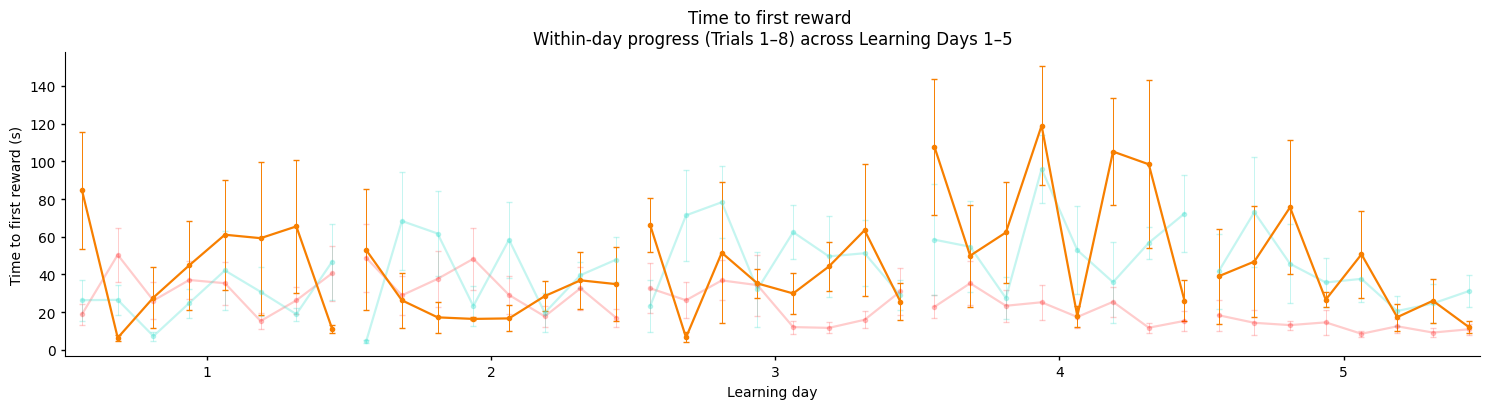

In [347]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Base filter: usable, relevant genotypes, L/SL learning days 1–5
#    (exclude missing t_to_trigger == 0)
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 1) trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_all.columns), None)

if trial_col is not None:
    meta_all['trial_in_day'] = meta_all[trial_col].astype(int)
else:
    meta_all = meta_all.sort_values(['sub', 'ses']).copy()
    meta_all['trial_in_day'] = meta_all.groupby(['sub', 'ses']).cumcount() + 1

meta_all = meta_all[meta_all['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 2) Helper: subject×trial matrix for a given day (allow missing trials)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if np.all(np.isnan(vals)):
            continue
        rows.append(vals)

    if len(rows) == 0:
        return None
    return np.vstack(rows)

# ------------------------------------------------------------
# 3) Build per-group meta for within-day curves
#    (Group 1: ChR2 long L; Group 2: eYFP L; Group 3: ChR2 short SL)
# ------------------------------------------------------------
def select_group(meta_all, genotype, learning_type='L', short_duration_val=None):
    m = meta_all[
        (meta_all['genotype'] == genotype) &
        (meta_all['trial_type'] == learning_type)
    ].copy()
    if short_duration_val is not None:
        m = m[m['short_duration'] == short_duration_val].copy()
    return m

meta_ChR2_long = select_group(meta_all, 'ChR2', learning_type='L',  short_duration_val=0)
meta_eYFP      = select_group(meta_all, 'eYFP_ChR2', learning_type='L', short_duration_val=None)
meta_ChR2_short= select_group(meta_all, 'ChR2', learning_type='SL', short_duration_val=1)

print("Animals included (n):")
print("  ChR2 long (L, short_duration=0):", meta_ChR2_long['sub'].nunique())
print("  eYFP_ChR2 (L):", meta_eYFP['sub'].nunique())
print("  ChR2 short (SL, short_duration=1):", meta_ChR2_short['sub'].nunique())

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            elinewidth=0.7,
            capsize=2,
            markersize=3
        )

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# ChR2 long – red
plot_within_day_curves(ax, meta_ChR2_long, color='red', alpha=0.2)

# eYFP control – turquoise, faded
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)

# ChR2 short (SL) – orange
plot_within_day_curves(ax, meta_ChR2_short, color='#f77f00', alpha=1)

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# center day labels under each day's curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Time to first reward \n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)
#(≥2 s stay)


style_nature(ax)
plt.tight_layout()
plt.show()

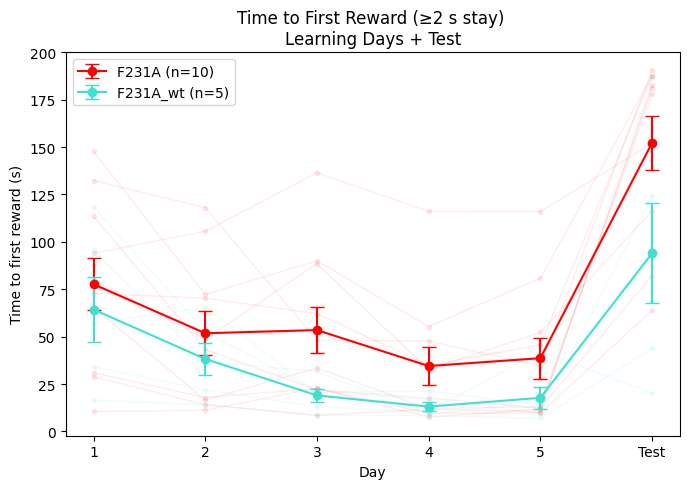

In [59]:
# time to arrive at new reward Ingo Greger animals - F231A vs wt and stayed there for at least 2 sec

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
             ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['t_to_trigger'] != 0)          # <-- exclude animals/trials with no data yet
].copy()

# Create "plot_day": learning = 1–5, test = 6 (assigned later)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # this animal has no test day

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect 6 days: L1–L5 + Test
plot_days = np.arange(1, 7)

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean time to first reward per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_F231A = meta_LT[meta_LT['genotype'] == 'F231A']
meta_F231A_wt = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_F231A, subs_F231A = build_genotype_matrix(meta_F231A)
mat_F231A_wt, subs_F231A_wt = build_genotype_matrix(meta_F231A_wt)



# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ---- ChR2 (red) ----
if mat_F231A is not None:
    # individual traces
    for row in mat_F231A:
        plt.plot(x_vals, row / 1000, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')

    # mean ± SEM
    mean_c = np.nanmean(mat_F231A, axis=0)
    sem_c  = np.nanstd(mat_F231A, axis=0) / np.sqrt(mat_F231A.shape[0])
    plt.errorbar(
        x_vals, mean_c / 1000, yerr=sem_c / 1000,
        fmt='-o', color='red', capsize=5,
        label=f'F231A (n={len(subs_F231A)})'
    )

# ---- eYFP (turquoise) ----
if mat_F231A_wt is not None:
    for row in mat_F231A_wt:
        plt.plot(x_vals, row / 1000, '-o', color='turquoise', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')

    mean_y = np.nanmean(mat_F231A_wt, axis=0)
    sem_y  = np.nanstd(mat_F231A_wt, axis=0) / np.sqrt(mat_F231A_wt.shape[0])
    plt.errorbar(
        x_vals, mean_y / 1000, yerr=sem_y / 1000,
        fmt='-o', color='turquoise', capsize=5,
        label=f'F231A_wt (n={len(subs_F231A_wt)})'
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay) \nLearning Days + Test')
#(≥2 s stay)
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()



ChR2 long (short_duration=0) animals in data: 12
ChR2 long animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
ChR2 short (short_duration=1) animals in data: 4
ChR2 short animals plotted: 4


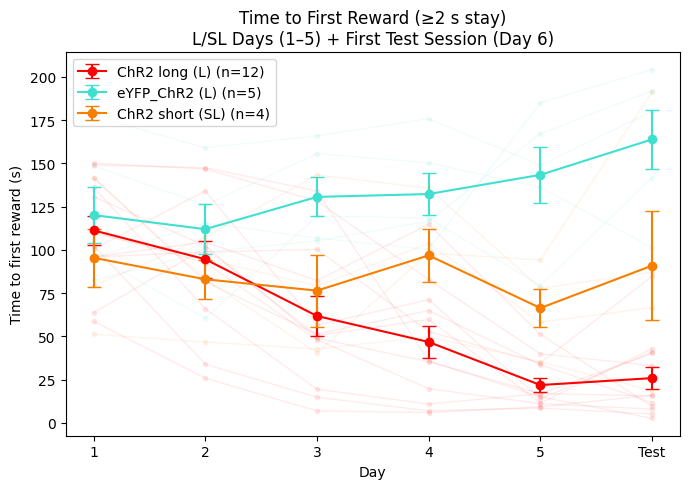

In [331]:
# time to arrive at reward ChR2 vs short_duration vs YFP and stayed there for at least 2 sec

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
#    (don't filter on short_duration here; we handle per-group)
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # L1–L5 + Test


# ------------------------------------------------------------
# 1. Helper to build subject × day matrix for a given group
#    learning_type: 'L' (normal) or 'SL' (short-duration learning)
#    short_duration_val: None (no filter), 0 or 1
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type, short_duration_val=None,
                       require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) t_to_trigger (ms)
      - subjects: list of subject IDs
    learning_type: 'L' or 'SL'
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> keep only those rows with that short_duration
    """
    # subset by genotype and learning trial type + T
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    # We'll create a plot_day per animal *for this group*
    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # Reset plot_day (so we don't reuse from other groups)
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Assign learning days = trial_type_day (expected 1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # Use 'ses' to find first T session after the last learning session
        last_L_ses = mL['ses'].max()

        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            # no test after learning for this animal in this group
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # Now compute mean t_to_trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # Build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce complete 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration = 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: ChR2, short_duration = 1, learning_type = 'SL'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 controls
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short-duration -> use SL trials as learning
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True  # can relax to False if needed
)

print("ChR2 long (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 long animals plotted:", len(subs_ChR2_long))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("ChR2 short (short_duration=1) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 1)]['sub'].nunique())
print("ChR2 short animals plotted:", len(subs_ChR2_short))

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # Individual traces (more faded)
    for row in mat:
        plt.plot(x_vals, row / 1000, '-o', color=color, alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # Group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_ / 1000, yerr=sem_ / 1000,
        fmt='-o', color=color, capsize=5,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 long – red
plot_group(mat_ChR2_long, subs_ChR2_long, color='red', label='ChR2 long (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: ChR2 short – more orange
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay)\nL/SL Days (1–5) + First Test Session (Day 6)')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

ChR2 (short_duration=0) animals in data: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
Hp animals in data: 7
Hp animals plotted: 7


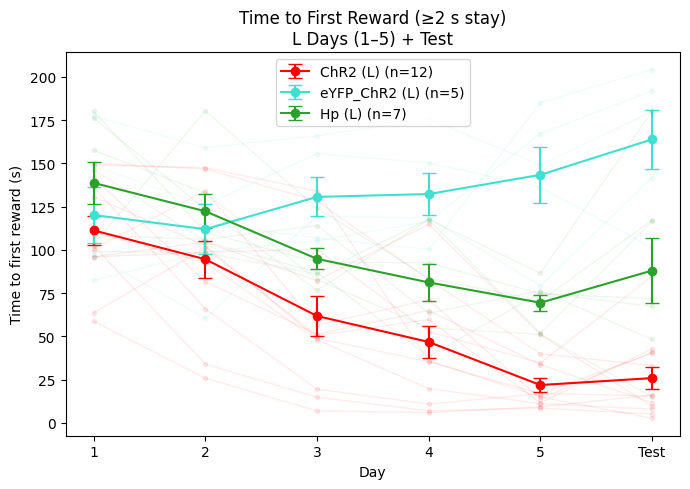

In [330]:
# time to arrive at reward: ChR2 vs eYFP_ChR2 vs Hp
# L days + first T session after learning; stayed there for at least 2 sec (via t_to_trigger)

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

plot_days = np.arange(1, 7)  # L1–L5 + Test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for a given group
#    learning_type: 'L' (we’re not using SL anymore here)
#    short_duration_val: None (no filter), 0 or 1
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L', short_duration_val=None,
                       require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) t_to_trigger (ms)
      - subjects: list of subject IDs

    learning_type: usually 'L'
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> keep only those rows with that short_duration
    """
    # subset by genotype and learning trial type + T
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # Reset plot_day for this animal
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Assign learning days = trial_type_day (expected 1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # Use 'ses' to find first T session after the last learning session
        last_L_ses = mL['ses'].max()

        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            # no test after learning for this animal
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # Now compute mean t_to_trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # Build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce complete 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration = 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: Hp, any short_duration, learning_type = 'L'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2, subs_ChR2 = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: Hp
mat_Hp, subs_Hp = build_group_matrix(
    meta_all,
    genotype='Hp',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

print("ChR2 (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("Hp animals in data:",
      meta_all[meta_all['genotype'] == 'Hp']['sub'].nunique())
print("Hp animals plotted:", len(subs_Hp))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # Individual traces (faded)
    for row in mat:
        plt.plot(x_vals, row / 1000, '-o', color=color, alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # Group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_ / 1000, yerr=sem_ / 1000,
        fmt='-o', color=color, capsize=5,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 – red
plot_group(mat_ChR2, subs_ChR2, color='red', label='ChR2 (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: Hp – green
plot_group(mat_Hp, subs_Hp, color='#2ca02c', label='Hp (L)')

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay)\nL Days (1–5) + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

In [303]:
# COMPUTE time to arrive for each trigger separately

# ----- COMPUTE TIME TO TRIGGER (ANY) + PER-TRIGGER TIMES -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)  # only recruit usable trials

# Define columns in metadata
metadata['t_to_trigger'] = 0          # time to first trigger (any trigger) with ≥2 s stay
metadata['learned'] = False           # ever stayed ≥2 s in any trigger?

R_TRIGGER = (10/1.2)  # radius defining trigger zone

# NEW: store per-trigger times here
trigger_rows = []  # each row: {trial_id, trigger_id, t_to_trigger_trig}

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None:
        continue

    cheeseboardMap = util.load_cheeseboard_map()
    triggerLoc = dl.get_data('triggerLoc')

    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

        # per-trigger: if we know nothing, set all triggers to trial duration
        for trig_id in range(1, trigger_num + 1):
            trigger_rows.append({
                'trial_id': trial_id,
                'trigger_id': trig_id,
                't_to_trigger_trig': t_to_trigger
            })
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
    
    # decide if we want visits with duration > 2000 ms (2 s) only or all visits
    # df_all_triggers_long = df_all_triggers[df_all_triggers['duration'] >= 2000]
    df_all_triggers_long = df_all_triggers

    # ---- original "first reward anywhere" metric ----
    if len(df_all_triggers_long) == 0:
        # never stayed ≥2 s in any trigger → use trial duration
        t_to_trigger = position_.iloc[-1]['t']
    else:
        t_to_trigger = df_all_triggers_long.iloc[0]['t_enter']
        metadata.at[trial_id, 'learned'] = True

    metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

    # ---- NEW: per-trigger times (first 2s stay in each trigger separately) ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers_long[df_all_triggers_long['trigger_id'] == trig_id]
        if len(df_t) == 0:
            # never stayed ≥2 s in THIS trigger → use trial duration
            t_trig = position_.iloc[-1]['t']
        else:
            t_trig = df_t.iloc[0]['t_enter']

        trigger_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            't_to_trigger_trig': t_trig
        })

# Build long-format per-trigger DataFrame and attach metadata columns
df_trig = pd.DataFrame(trigger_rows)

meta_trig = df_trig.merge(
    metadata,
    left_on='trial_id',   # integer from the loop
    right_index=True,     # metadata index 0..len-1
    how='left'
)




 15%|█▌        | 709/4613 [00:07<00:40, 96.20it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1180/4613 [00:12<00:35, 96.25it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2607/4613 [00:26<00:14, 141.13it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4613/4613 [00:40<00:00, 113.38it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-01_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-02_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-03_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-04_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-05_data-position.csv' does not exist.
The f

Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs:
[np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs:
[np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


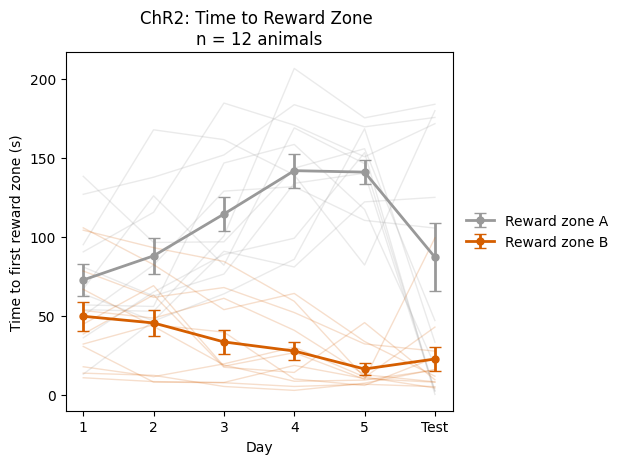

In [305]:
# PLOT time to arrive for ChR2 group

# PLOT time to arrive for remapping group (L1–L5 + first T on Day 6), 2 reward zones (A, B)

import numpy as np
import matplotlib.pyplot as plt

# ----- FILTER FOR ChR2, L/T, NOT SHORT, AND ASSIGN DAYS -----

mt = meta_trig[
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['L', 'T']))
].copy()

mt['plot_day'] = np.nan

# L days: use trial_type_day (1..5)
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last L session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (trigger_id) -----

def build_zone_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER REWARD ZONE, INDIVIDUAL + MEAN -----

plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

# Paper-style, colorblind-friendly colors
colors = {
    1: '#999999',  # blue
    2: '#D55E00',  # orange
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,   # ms → s
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

        # ---- label at end (Test day) ----
         # plt.text(
          #    x_vals[-1] + 0.05,   # slightly to the right of Day 6
          #    y_vals[-1],
           #   str(sub),
            #  fontsize=7,
            #  color=colors[zid],
           #   alpha=0.7,
           #   va='center'
         # )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )



plt.xlabel('Day')
plt.ylabel('Time to first reward zone (s)')
plt.title(
    f'ChR2: Time to Reward Zone \n'
    # f'ChR2: Time to Reward Zone (≥2 s stay)\n'

    f'n = {n_animals} animals',
    fontsize=12
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


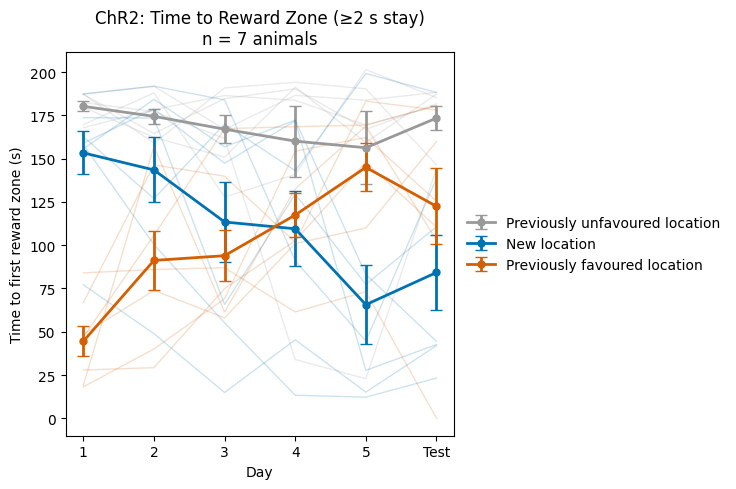

In [294]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, INDIVIDUAL + MEAN -----

plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly, “paper” style colors (similar to ggplot2 palette)
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location (highlighted)
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,                # ms → s
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward zone (s)')
plt.title(
    f'ChR2: Time to Reward Zone (≥2 s stay)\n'
    f'n = {n_animals} animals',
    fontsize=12
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout()
plt.show()




In [ ]:
```   # colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the color.
    genotype_color = {}
    genotype_color['S305N-hTau'] = '#fd3f41ff'
    genotype_color['wt-hTau'] =  "#5ba0d8ff"
    genotype_color['ywt-hTau'] = 'b'
    genotype_color['yS305N-hTau'] = 'r'
    genotype_color['C'] = '#66c2a5'
    genotype_color['D'] = '#fc8d62'
    genotype_color['wt'] = 'grey'
    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]
```

Pct time in trigger zone

In [41]:
# plot pct time in trigger zone


metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
  
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    total_time_in_trigger = df_all_triggers['duration'].sum()

    # Trial duration: max time in this trial (same units as duration)
    trial_duration = position_['t'].max()

    if trial_duration > 0:
        pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    else:
        pct_time_in_trigger = np.nan

    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger


 15%|█▌        | 701/4611 [00:06<00:37, 105.56it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1185/4611 [00:11<00:33, 103.76it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2615/4611 [00:22<00:11, 174.74it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:38<00:00, 121.14it/s]


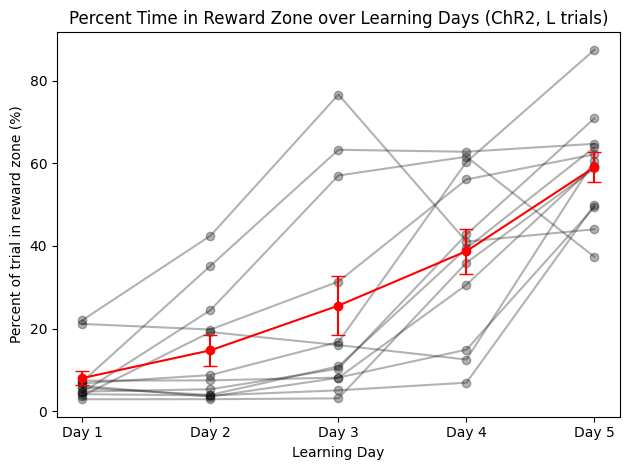

In [73]:
# Restrict to ChR2 learning trials
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].reset_index(drop=True)

performance_mat = []

plt.figure()

for sub in metadata_L['sub'].unique():
    meta_sub = metadata_L[metadata_L['sub'] == sub]

    # Mean % time in trigger zone per training day
    mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
    mean_pct_by_day = mean_pct_by_day.sort_index()

    # Expect 5 days; skip incomplete animals
    if len(mean_pct_by_day) != 5:
        continue

    performance_mat.append(mean_pct_by_day.values)

    # Individual subject traces (thin black)
    plt.plot(range(5), mean_pct_by_day.values, '-o', color='k', alpha=0.3)

# Group mean ± SEM
performance_mat = np.vstack(performance_mat)
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])

plt.errorbar(
    range(5),
    mean_performance,
    yerr=sem_performance,
    fmt='-o',
    color='r',
    capsize=5
)

plt.xlabel('Learning Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone over Learning Days (ChR2, L trials)')
plt.xticks(range(5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])
plt.tight_layout()
plt.show()

ChR2 animals in meta_ChR2: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


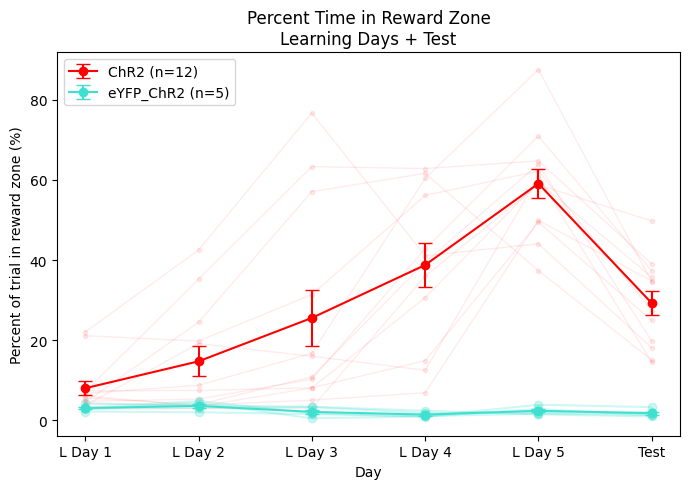

In [115]:
# plot ChR2 & eYFP_ChR2 learning trials + first test day (by session) after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2: red
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(x_vals, row, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(x_vals, mean_c, yerr=sem_c, fmt='-o', color='red',
                 capsize=5, label=f'ChR2 (n={len(subs_ChR2)})')

# eYFP_ChR2: turquoise
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(x_vals, row, '-o', color='turquoise', alpha=0.25, label='_nolegend_')
    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(x_vals, mean_y, yerr=sem_y, fmt='-o', color='turquoise',
                 capsize=5, label=f'eYFP_ChR2 (n={len(subs_eYFP)})')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 10
  eYFP_ChR2: 5


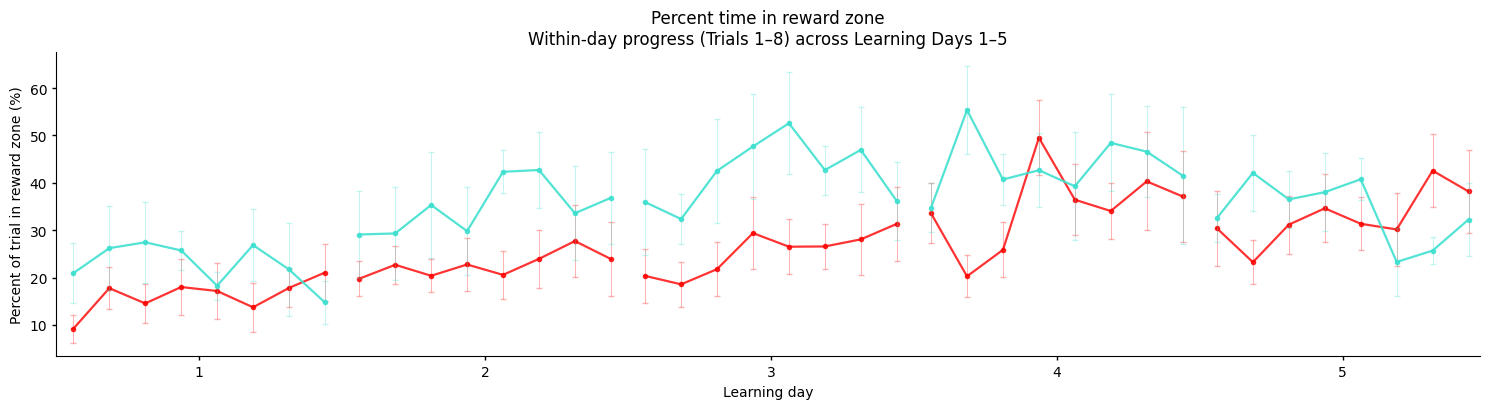

In [49]:

# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_time_in_trigger (% of trial in reward zone)
# Groups: ChR2 vs eYFP_ChR2
# Notes:
#   - excludes short_duration == 1
#   - excludes trials with pct_time_in_trigger missing/NaN
#   - allows missing trials within a day (curve will use available points)
# ============================================================

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    #    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
  #  (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
   #    (metadata['trial_type'].isin(['L', 'SL'])) &

    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['pct_time_in_trigger'].notna())
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_time_in_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials])
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # ---- mean line (normal alpha) ----
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # ---- SEM bars only (more faded) ----
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),   # <- SEM transparency (faded)
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Split by genotype
# ------------------------------------------------------------
#meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
#meta_Hp   = meta_L[meta_L['genotype'] == 'Hp']
meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# if plotting for short duration
#meta_ChR2_long = meta_L[
#    (meta_L['genotype'] == 'ChR2') &
#    (meta_L['trial_type'] == 'L') &
#    (meta_L['short_duration'] == 0)
#].copy()

#meta_ChR2_short = meta_L[
#    (meta_L['genotype'] == 'ChR2') &
#    (meta_L['trial_type'] == 'SL') &
#    (meta_L['short_duration'] == 1)
#].copy()

# meta_eYFP = meta_L[
#    (meta_L['genotype'] == 'eYFP_ChR2') &
#    (meta_L['trial_type'] == 'L')
#].copy()

print("Animals included (n):")
#print("  ChR2 long :", meta_ChR2_long['sub'].nunique())
#print("  ChR2 short:", meta_ChR2_short['sub'].nunique())
#print("  eYFP      :", meta_eYFP['sub'].nunique())

print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
#print("  Hp:", meta_Hp['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot (wider; centered day labels under each day's curve)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red', alpha=0.8)
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.9)  # control more faded
#plot_within_day_curves(ax, meta_Hp,   color='#2ca02c',    alpha=0.9)

#plot_within_day_curves(ax, meta_ChR2_long,  color='red', alpha=0.25)
#plot_within_day_curves(ax, meta_ChR2_short, color='#f77f00', alpha=1.0)   # orange
#plot_within_day_curves(ax, meta_eYFP,       color='turquoise', alpha=0.45)  # faded control

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.tight_layout()
plt.show()

Animals included per reward zone:
  Reward zone 1: 12 animals
  Reward zone 2: 12 animals

Total unique animals included (any zone): 12
Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]


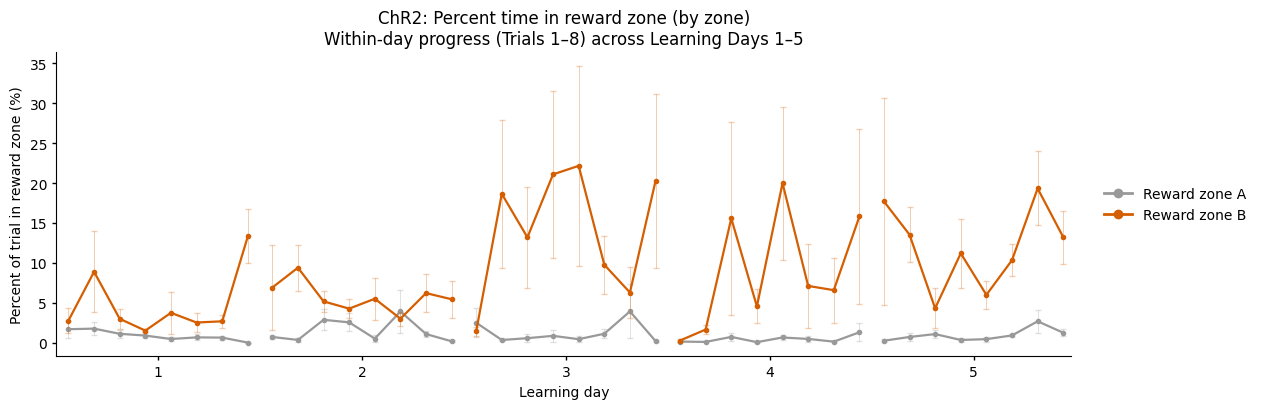

In [ ]:

# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_in_trigger_trig (% of trial in reward zone)
# Group: ChR2 only
# Separate curves for trigger_id 1 and 2 (Reward zone A/B)
# Notes:
#   - excludes short_duration == 1
#   - allows missing trials within a day (curve uses available points)
#   - no individual background traces (mean ± SEM only)
# ============================================================

# ----------------------------
# SETTINGS
# ----------------------------
days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)
zone_ids = [1, 2]

colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

# ------------------------------------------------------------
# 1) Filter meta_pct: ChR2, L only, days 1–5, NOT short
# ------------------------------------------------------------
meta_L = meta_pct[
    (meta_pct['usable'] == 1) &
 #   (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'SL') &
    (meta_pct['trial_type_day'].isin(days)) &
    (meta_pct['trigger_id'].isin(zone_ids)) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 based on UNIQUE TRIALS (not rows)
#    so trigger A and B share the same trial number
# ------------------------------------------------------------

# Use a stable per-trial key
if 'trial_id' not in meta_L.columns:
    # fallback: if you don't have trial_id, use the index as trial id
    meta_L = meta_L.reset_index().rename(columns={'index': 'trial_id'})

# Build a per-trial table (one row per real trial)
trial_table = (
    meta_L[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

# Assign trial numbers within each session (or within each day — see note below)
trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1

# Keep only trials 1..8
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

# Merge back so BOTH triggers get the SAME trial_in_day
meta_L = meta_L.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day AND zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id):
    md = meta_g[(meta_g['trial_type_day'] == day) & (meta_g['trigger_id'] == zone_id)]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, meta_g, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        meta_L,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Center ticks under each day curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Make sure day 5 curve fully visible and reduce left whitespace
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'ChR2: Percent time in reward zone (by zone)\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color='#999999', lw=2, marker='o', label='Reward zone A'),
    Line2D([0], [0], color='#D55E00', lw=2, marker='o', label='Reward zone B'),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Animal counts (based on *this* filtered dataset)
# ------------------------------------------------------------
subs_zone = {
    zid: sorted(meta_L.loc[meta_L['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}

print("Animals included per reward zone:")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

ChR2 animals in meta_ChR2: 10
ChR2 animals plotted: 10
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


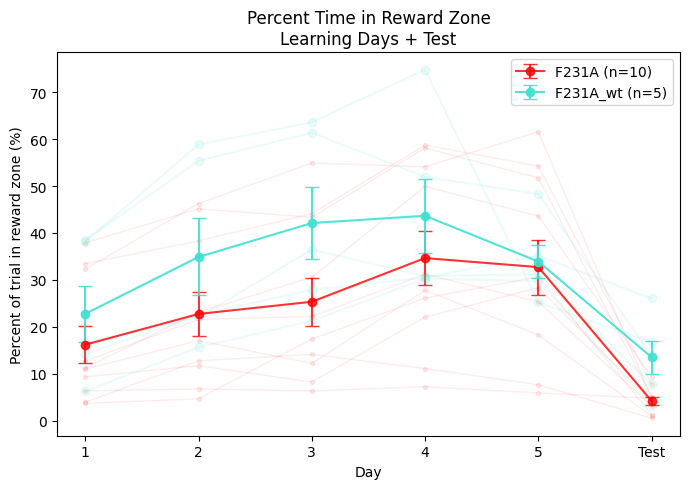

In [48]:
# plot f231a vs wt learning trials + first test day (by session) after learning


# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2: red
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(x_vals, row, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(x_vals, mean_c, yerr=sem_c, fmt='-o', color='red', alpha=0.8,
                 capsize=5, label=f'F231A (n={len(subs_ChR2)})')

# eYFP_ChR2: turquoise
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(x_vals, row, '-o', color='turquoise', alpha=0.1, label='_nolegend_')
    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(x_vals, mean_y, yerr=sem_y, fmt='-o', color='turquoise', alpha=0.90,
                 capsize=5, label=f'F231A_wt (n={len(subs_eYFP)})')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

ChR2 long (short_duration=0) animals in data: 12
ChR2 long animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
ChR2 short (short_duration=1) animals in data: 4
ChR2 short animals plotted: 4


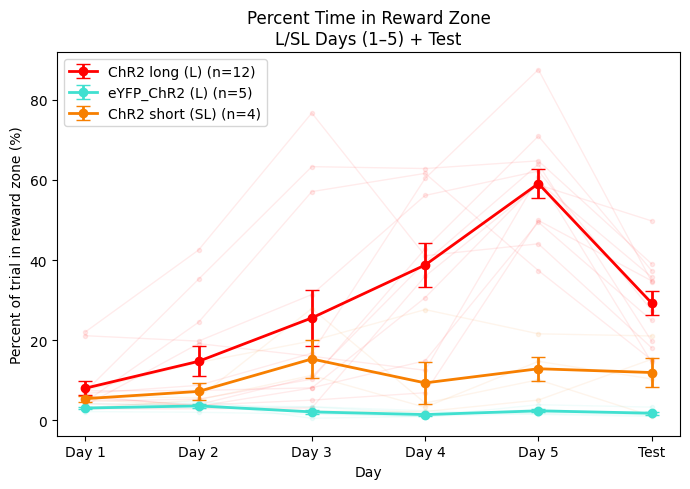

In [ ]:
# =============================================================
# Build subject × day performance matrices for 3 groups:
# percent time in trigger zone over learning days + test

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1. Helper to build subject × day matrix for a group
#    learning_type: 'L' or 'SL'
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning trials)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # genotype + (learning_type or T)
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # use 'ses' to find first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration == 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: ChR2, short_duration == 1, learning_type = 'SL'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 long animals plotted:", len(subs_ChR2_long))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("ChR2 short (short_duration=1) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 1)]['sub'].nunique())
print("ChR2 short animals plotted:", len(subs_ChR2_short))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # faded individual traces
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )
    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o', color=color,
        capsize=5,
        linewidth=2,
        markersize=6,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 long – red
plot_group(mat_ChR2_long, subs_ChR2_long, color='red', label='ChR2 long (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: ChR2 short – orange
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nL/SL Days (1–5) + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

ChR2 animals in data: 12
ChR2 animals plotted: 12
eYFP animals in data: 5
eYFP animals plotted: 5
Hp animals in data: 7
Hp animals plotted: 7


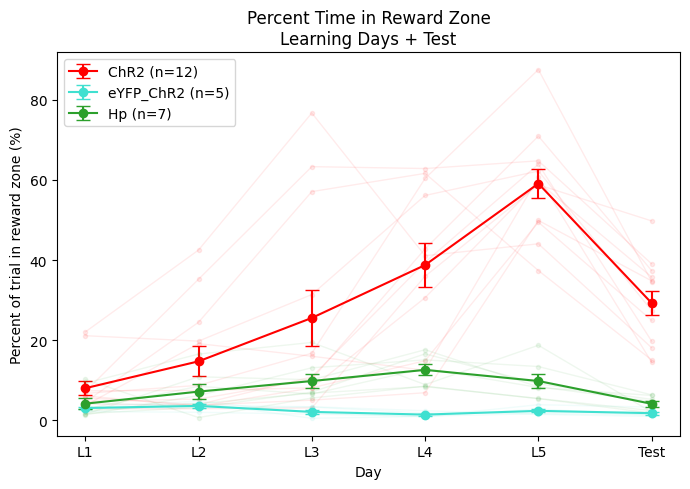

In [98]:
# plot ChR2 & eYFP_ChR2 & Hp learning trials + test after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable animals, 3 genotypes, L or T trials
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create plot_day:
# - L trials → trial_type_day 1–5
# - T trials → set later to day 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']


# ---------------------------------------------------------------------
# 1b. Assign the first T *session* after the last L session to plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6


plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test session


# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs
    Only keeps animals with complete 1–6 days.
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue   # require complete 6 days

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ---------------------------------------------------------------------
# 3. Build matrices for the three groups
# ---------------------------------------------------------------------
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp)

print("ChR2 animals in data:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP animals in data:", meta_eYFP['sub'].nunique())
print("eYFP animals plotted:", len(subs_eYFP))
print("Hp animals in data:", meta_Hp['sub'].nunique())
print("Hp animals plotted:", len(subs_Hp))


# ---------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # individual traces
    for row in mat:
        plt.plot(x_vals, row, '-o', color=color, alpha=0.08, linewidth=1, markersize=3,label='_nolegend_')

    # group mean ± sem
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_, fmt='-o', color=color,
        capsize=5, label=f'{label} (n={len(subs)})'
    )


# Plot groups
plot_group(mat_ChR2, subs_ChR2, color='red',     label='ChR2')
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2')
plot_group(mat_Hp,   subs_Hp,   color='#2ca02c', label='Hp')


plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['L1','L2','L3','L4','L5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

Compute percentage of time spent in reward zone for REMAPPING group


In [391]:
# ----- COMPUTE PERCENT TIME IN TRIGGER ZONE (PER TRIGGER) -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone (like your example)
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

pct_rows = []  # will hold per-trigger rows: trial_id, trigger_id, pct_in_trigger_trig

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Trial duration (same units as df_trigger_interaction['duration'])
    trial_duration = position_['t'].max()
    if trial_duration <= 0:
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    # ---- ANY trigger, like your original code ----
    total_time_in_trigger = df_all_triggers['duration'].sum()
    pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger

    # ---- PER TRIGGER: same logic, but restricted to each trigger_id ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
        if len(df_t) == 0:
            pct_trig = 0.0   # spent 0% of time in this trigger
        else:
            total_t_trig = df_t['duration'].sum()
            pct_trig = 100.0 * total_t_trig / trial_duration

        pct_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'pct_in_trigger_trig': pct_trig
        })

# Long-format per-trigger table + metadata
df_pct = pd.DataFrame(pct_rows)
meta_pct = df_pct.merge(metadata, left_on='trial_id', right_index=True, how='left')

 15%|█▌        | 704/4613 [00:07<00:37, 103.02it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1177/4613 [00:12<00:34, 98.22it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2611/4613 [00:25<00:13, 149.02it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4613/4613 [00:38<00:00, 118.64it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-01_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-02_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-03_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-04_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-056_id-BJ/ses-01_date-20251214/behav/sub-056_ses-01_trial-05_data-position.csv' does not exist.
The f

Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


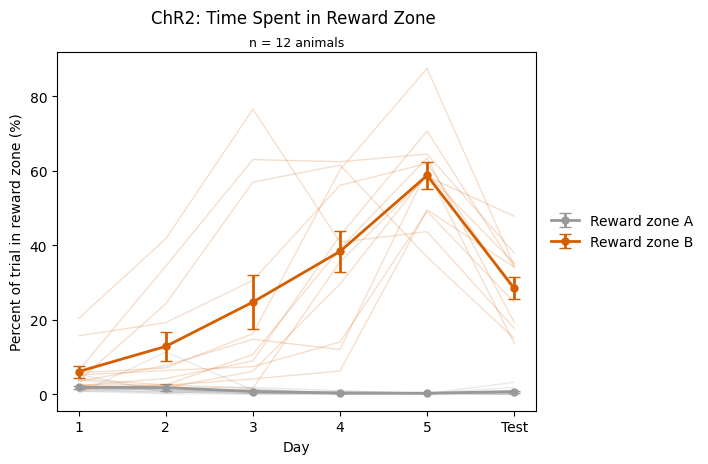

In [281]:
# ----- FILTER: ChR2, L/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['L', 'T']))
].copy()

# L days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5 for L trials
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (PERCENT TIME) -----

def build_zone_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix_pct(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Paper-style colors for A/B
colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # individual animals (faded) + ID labels at end
    for row, sub in zip(mat, subs):
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )


    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)
ax.text(
    0.5, 1.01,
    f'n = {n_animals} animals',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

Animals included per reward zone:
  Reward zone 1: 4 animals
  Reward zone 2: 4 animals

Total unique animals included (any zone): 4
Animal IDs: [np.int64(13), np.int64(14), np.int64(15), np.int64(17)]


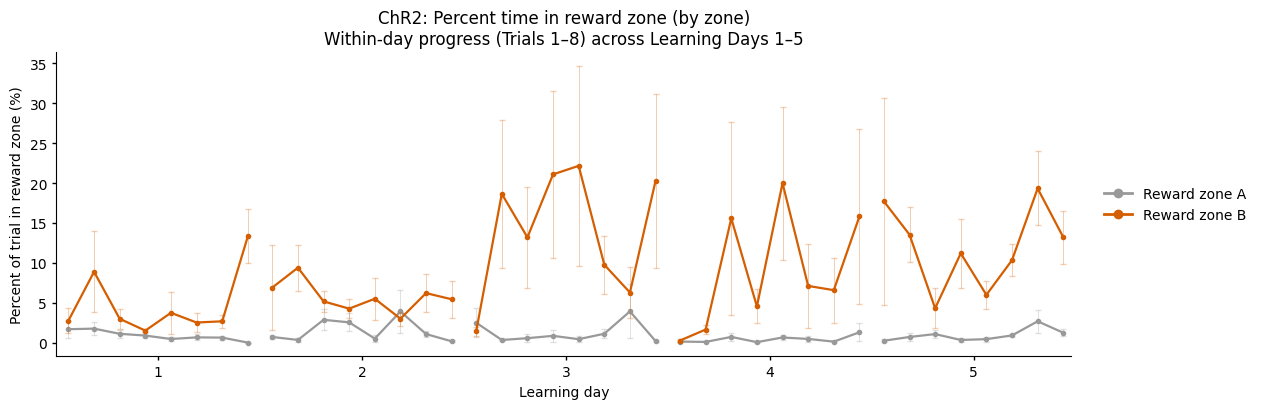

In [395]:

# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_in_trigger_trig (% of trial in reward zone)
# Group: ChR2 only
# Separate curves for trigger_id 1 and 2 (Reward zone A/B)
# Notes:
#   - excludes short_duration == 1
#   - allows missing trials within a day (curve uses available points)
#   - no individual background traces (mean ± SEM only)
# ============================================================

# ----------------------------
# SETTINGS
# ----------------------------
days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)
zone_ids = [1, 2]

colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

# ------------------------------------------------------------
# 1) Filter meta_pct: ChR2, L only, days 1–5, NOT short
# ------------------------------------------------------------
meta_L = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] == 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'SL') &
    (meta_pct['trial_type_day'].isin(days)) &
    (meta_pct['trigger_id'].isin(zone_ids)) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 based on UNIQUE TRIALS (not rows)
#    so trigger A and B share the same trial number
# ------------------------------------------------------------

# Use a stable per-trial key
if 'trial_id' not in meta_L.columns:
    # fallback: if you don't have trial_id, use the index as trial id
    meta_L = meta_L.reset_index().rename(columns={'index': 'trial_id'})

# Build a per-trial table (one row per real trial)
trial_table = (
    meta_L[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

# Assign trial numbers within each session (or within each day — see note below)
trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1

# Keep only trials 1..8
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

# Merge back so BOTH triggers get the SAME trial_in_day
meta_L = meta_L.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day AND zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id):
    md = meta_g[(meta_g['trial_type_day'] == day) & (meta_g['trigger_id'] == zone_id)]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, meta_g, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        meta_L,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Center ticks under each day curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Make sure day 5 curve fully visible and reduce left whitespace
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'ChR2: Percent time in reward zone (by zone)\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color='#999999', lw=2, marker='o', label='Reward zone A'),
    Line2D([0], [0], color='#D55E00', lw=2, marker='o', label='Reward zone B'),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)


# Animal counts 
subs_zone = {
    zid: sorted(meta_L.loc[meta_L['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}

print("Animals included per reward zone:")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


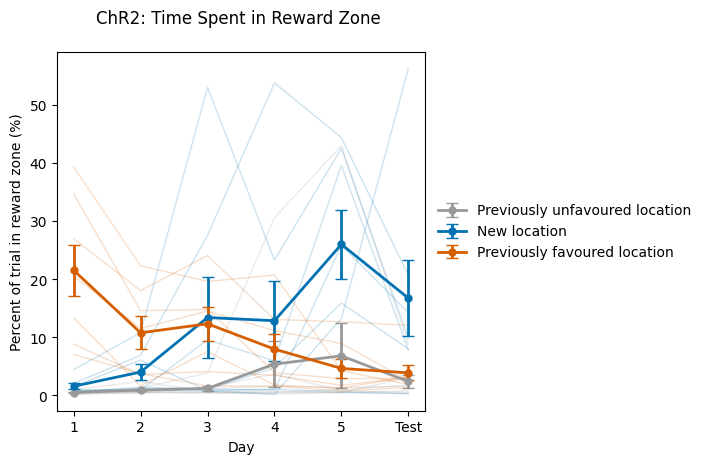

In [208]:
# ----- FILTER: ChR2, RL/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['RL', 'T']))
].copy()

# RL days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 for RL trials
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last RL session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER (PERCENT TIME) -----

def build_trigger_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean % time per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix_pct(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row,                      # already in %
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

# Main title + smaller n-line
plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)


plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()


Compute number of crossings

In [50]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: number of crossings into ANY trigger zone
metadata['n_crossings'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'n_crossings'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Build visit episodes for each trigger
    dfs = []
    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        if len(df_trigger_interaction) == 0:
            continue
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    # Number of crossings = number of visits to any trigger
    if len(dfs) == 0:
        n_crossings = 0
    else:
        df_all_triggers = pd.concat(dfs, ignore_index=True)
        # (sorting not required for counting, but harmless)
        # df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
        n_crossings = len(df_all_triggers)

    metadata.at[trial_id, 'n_crossings'] = n_crossings

 15%|█▌        | 708/4611 [00:06<00:33, 115.50it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1181/4611 [00:10<00:30, 111.28it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2622/4611 [00:22<00:11, 168.14it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:37<00:00, 121.55it/s]


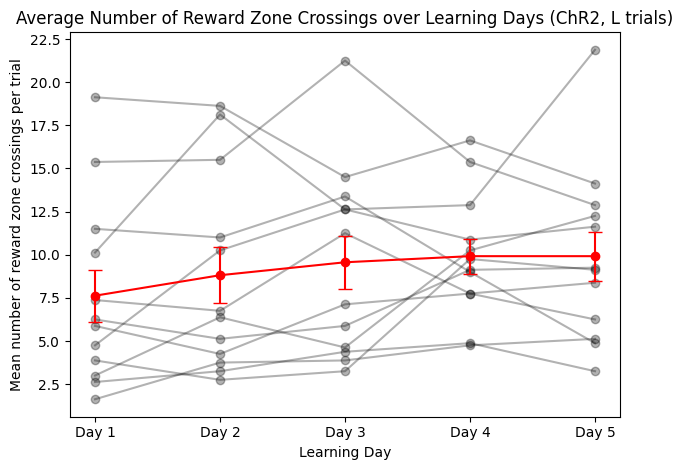

In [37]:
# number of crossings. Restrict to ChR2 learning trials
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].reset_index(drop=True)

performance_mat = []

plt.figure()

for sub in metadata_L['sub'].unique():
    meta_sub = metadata_L[metadata_L['sub'] == sub]

    # Mean number of crossings per day for this animal
    mean_crossings_by_day = meta_sub.groupby('trial_type_day')['n_crossings'].mean()
    mean_crossings_by_day = mean_crossings_by_day.sort_index()

    # Expect 5 days; skip animals missing days
    if len(mean_crossings_by_day) != 5:
        continue

    performance_mat.append(mean_crossings_by_day.values)

    # Individual animal trace (thin black)
    plt.plot(range(5), mean_crossings_by_day.values, '-o', color='k', alpha=0.3)

# Group mean ± SEM across animals
if len(performance_mat) > 0:
    performance_mat = np.vstack(performance_mat)
    mean_performance = np.nanmean(performance_mat, axis=0)
    sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])

    plt.errorbar(
        range(5),
        mean_performance,
        yerr=sem_performance,
        fmt='-o',
        color='r',
        capsize=5
    )

plt.xlabel('Learning Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Average Number of Reward Zone Crossings over Learning Days (ChR2, L trials)')
plt.xticks(range(5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])
plt.tight_layout()
plt.show()

ChR2 long animals plotted: 12
eYFP animals plotted: 5
ChR2 short animals plotted: 4


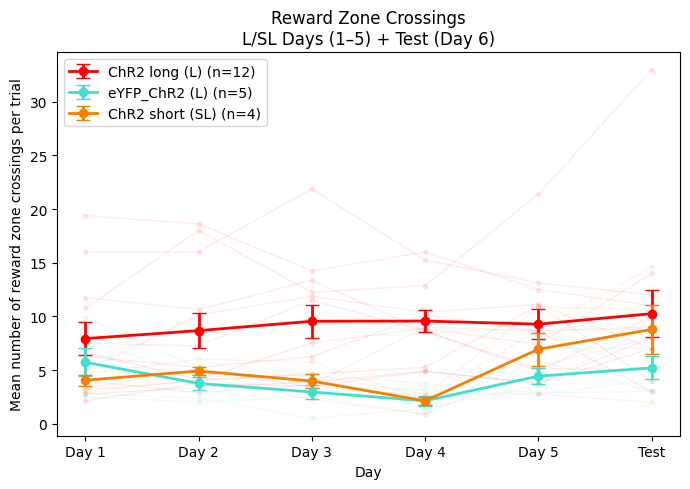

In [108]:
# number of crossings, ChR2 & eYFP_ChR2 & Short duration

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + day 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of n_crossings
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL'
    short_duration_val:
        None  -> ignore this column
        0 or 1 -> restrict to it
    """

    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Learning days = trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build vector [days 1–6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for 3 groups
# ------------------------------------------------------------

# Group 1: ChR2 long → L learning
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 → L learning
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short → SL learning
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long animals plotted:", len(subs_ChR2_long))
print("eYFP animals plotted:", len(subs_eYFP))
print("ChR2 short animals plotted:", len(subs_ChR2_short))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # convert to 0–5 indexing

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # faded single-animal lines
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )


# Plot the 3 groups
plot_group(mat_ChR2_long, subs_ChR2_long, color='red',       label='ChR2 long (L)')
plot_group(mat_eYFP,      subs_eYFP,      color='turquoise', label='eYFP_ChR2 (L)')
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')


plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Reward Zone Crossings\nL/SL Days (1–5) + Test (Day 6)')
plt.xticks(
    ticks=np.arange(6),
    labels=['Day 1','Day 2','Day 3','Day 4','Day 5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

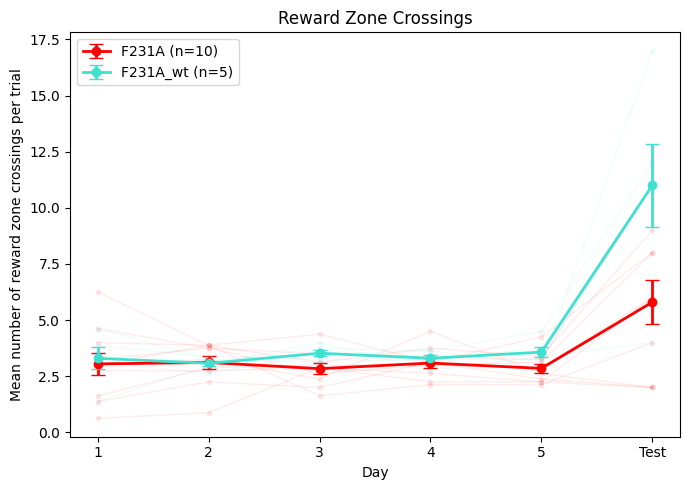

In [51]:
# number of crossings, F231a VS WT

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L','T'])) &
    (metadata['id'] != 'BQ')
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + day 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):

    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))


    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Learning days = trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build vector [days 1–6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for 3 groups
# ------------------------------------------------------------

# Group 1: ChR2 long → L learning
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='F231A',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 → L learning
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='F231A_wt',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # convert to 0–5 indexing

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # faded single-animal lines
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )


# Plot the 3 groups
plot_group(mat_ChR2_long, subs_ChR2_long, color='red',       label='F231A')
plot_group(mat_eYFP,      subs_eYFP,      color='turquoise', label='F231A_wt')


plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Reward Zone Crossings')
plt.xticks(
    ticks=np.arange(6),
    labels=['1','2','3','4','5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2 long : 10
  eYFP      : 5


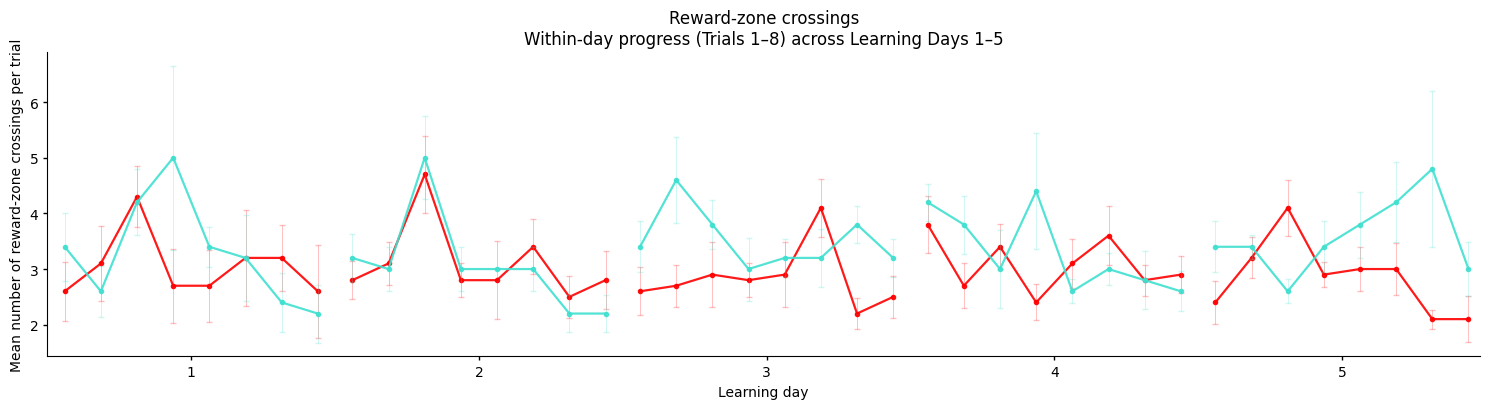

In [52]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: n_crossings (per trial)
# Groups are easy to toggle by commenting out blocks below.
# ============================================================

# ------------------------------------------------------------
# 1) Base filter (edit these lines to switch cohorts)
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &   # optional global exclusion
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    # (metadata['trial_type'].isin(['L', 'SL'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['n_crossings'].notna())        # <-- crossings metric
].copy()

days   = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) subject × trial matrix for a given day (allow missing trials)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['n_crossings'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: mean + faded SEM only (no individual traces)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean curve
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # faded SEM bars
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.25),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Define groups (COMMENT OUT whichever you don't want)
# ------------------------------------------------------------

# --- Group 1: ChR2 long (L, short_duration=0) ---
meta_ChR2_long = meta_L[
    #(meta_L['genotype'] == 'ChR2') &
    (meta_L['genotype'] == 'F231A') &
    (meta_L['trial_type'] == 'L') &
    (meta_L['short_duration'] == 0)
].copy()

# --- Group 2: ChR2 short (SL, short_duration=1) ---
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()

# --- Group 3: eYFP_ChR2 controls (L, any short_duration) ---
meta_eYFP = meta_L[
    #(meta_L['genotype'] == 'eYFP_ChR2') &
    (meta_L['genotype'] == 'F231A_wt') &
    (meta_L['trial_type'] == 'L')
].copy()

# --- Optional extra group example: Hp (if you enable Hp above) ---
# meta_Hp = meta_L[
#      (meta_L['genotype'] == 'Hp') &
#      (meta_L['trial_type'] == 'L')
#  ].copy()

print("Animals included (n):")
print("  ChR2 long :", meta_ChR2_long['sub'].nunique())
# print("  ChR2 short:", meta_ChR2_short['sub'].nunique())
print("  eYFP      :", meta_eYFP['sub'].nunique())
# print("  Hp        :", meta_Hp['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2_long,  color='red',      alpha=0.9)
# plot_within_day_curves(ax, meta_ChR2_short, color='#f77f00',  alpha=1)   # orange
plot_within_day_curves(ax, meta_eYFP,       color='turquoise', alpha=0.9) # faded control
# plot_within_day_curves(ax, meta_Hp,        color='#2ca02c',   alpha=0.9)  # optional

ax.set_xlabel('Learning day')
ax.set_ylabel('Mean number of reward-zone crossings per trial')

# day labels centered under each day's curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# reduce whitespace + ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Reward-zone crossings\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.tight_layout()
plt.show()

ChR2 (short_duration=0) animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


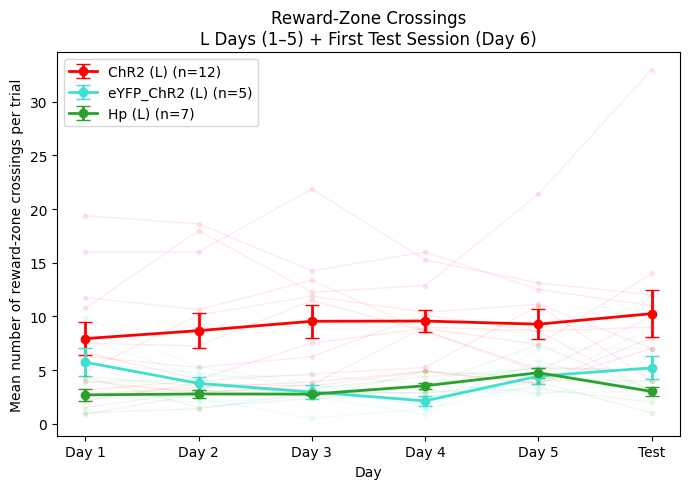

In [109]:
# number of crossings, ChR2 & eYFP_ChR2 & Hp

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, 3 genotypes, L/T
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix(meta_df, genotype, short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) n_crossings per day
      - subjects: list of subject IDs

    Learning trials are 'L', test is first 'T' session after last L session.
    short_duration_val:
        None -> no filter
        0 or 1 -> restrict to that value
    """

    # subset by genotype & trial type
    mask = (meta_df['genotype'] == genotype) & \
           (meta_df['trial_type'].isin(['L', 'T']))

    if short_duration_val is not None:
        mask &= (meta_df['short_duration'] == short_duration_val)

    meta_g = meta_df[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # learning trials (L) for this animal
        mL = ms[ms['trial_type'] == 'L']
        if len(mL) == 0:
            continue

        # assign L days 1–5 from trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last L session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per plot_day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
# ------------------------------------------------------------

# Group 1: ChR2 long (short_duration == 0)
mat_ChR2, subs_ChR2 = build_group_matrix(
    meta_LT,
    genotype='ChR2',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 (any short_duration)
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_LT,
    genotype='eYFP_ChR2',
    short_duration_val=None,
    require_complete=True
)

# Group 3: Hp (any short_duration)
mat_Hp, subs_Hp = build_group_matrix(
    meta_LT,
    genotype='Hp',
    short_duration_val=None,
    require_complete=True
)

print("ChR2 (short_duration=0) animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
print("Hp animals plotted:", len(subs_Hp))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # faded individual traces
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )


# Plot groups with your colour scheme
plot_group(mat_ChR2, subs_ChR2, color='red',      label='ChR2 (L)')
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')
plot_group(mat_Hp,   subs_Hp,   color='#2ca02c',  label='Hp (L)')

plt.xlabel('Day')
plt.ylabel('Mean number of reward-zone crossings per trial')
plt.title('Reward-Zone Crossings\nL Days (1–5) + First Test Session (Day 6)')
plt.xticks(
    ticks=np.arange(6),
    labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

Compute the number of crossings for REMAPPING group

In [209]:
# ----- COMPUTE NUMBER OF CROSSINGS (PER TRIGGER) -----

import numpy as np
import pandas as pd
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# Any-trigger version (kept for consistency)
metadata['n_crossings'] = np.nan

R_TRIGGER = (10/1.2)

cross_rows = []  # per-trigger rows

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'n_crossings'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    dfs = []
    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        if len(df_trigger_interaction) == 0:
            continue
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    # ANY trigger crossings (your original logic)
    if len(dfs) == 0:
        n_crossings = 0
        metadata.at[trial_id, 'n_crossings'] = 0
    else:
        df_all_triggers = pd.concat(dfs, ignore_index=True)
        n_crossings = len(df_all_triggers)
        metadata.at[trial_id, 'n_crossings'] = n_crossings

    # ---- PER TRIGGER: SAME LOGIC, but split ----
    for trig_id in range(1, len(triggerLoc) + 1):
        if len(dfs) == 0:
            n_trig = 0
        else:
            df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
            n_trig = len(df_t)

        cross_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'n_crossings_trig': n_trig
        })

# Long-format per-trigger table + metadata
df_cross = pd.DataFrame(cross_rows)
meta_cross = df_cross.merge(metadata, left_on='trial_id', right_index=True, how='left')

 20%|█▉        | 704/3576 [00:07<00:29, 97.02it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 33%|███▎      | 1182/3576 [00:12<00:22, 104.79it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 73%|███████▎  | 2622/3576 [00:25<00:06, 157.25it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 3576/3576 [00:33<00:00, 106.23it/s]


Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


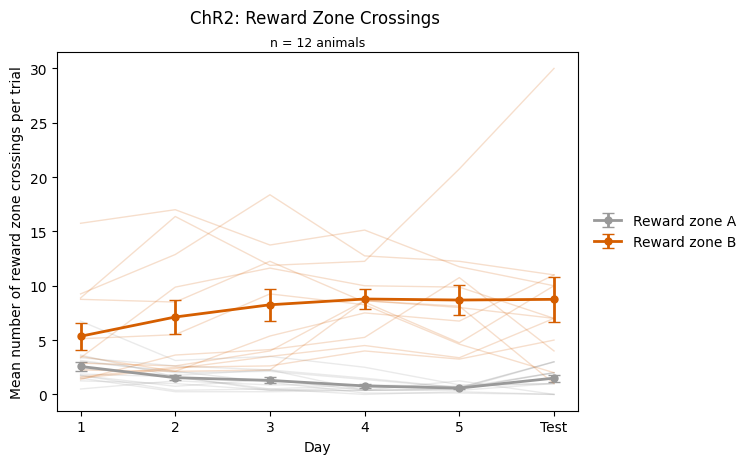

In [292]:
# ----- FILTER: ChR2, L/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_cross[
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'].isin(['L', 'T']))
].copy()

# L days
mt['plot_day'] = np.nan
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep L days 1–5 only
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T after last L as day 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (CROSSINGS) -----

def build_zone_matrix_cross(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['n_crossings_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}

for zid in zone_ids:
    mat, subs = build_zone_matrix_cross(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: NUMBER OF CROSSINGS (ChR2, ZONE A/B) -----

plt.figure(figsize=(9, 5))  # wider
x_vals = plot_days - 1

# requested: Reward zone A = grey
colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # faded individuals (no ID labels)
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    

    # mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')

plt.title('ChR2: Reward Zone Crossings \n', fontsize=12)
ax.text(
    0.5, 1.01,
    f'n = {n_animals} animals',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


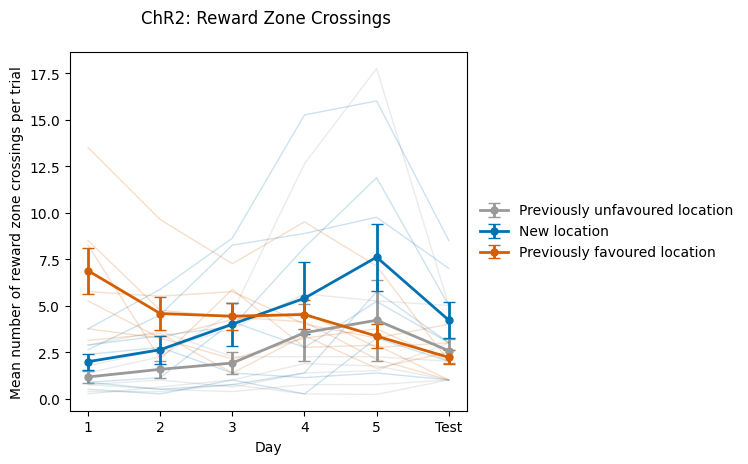

In [212]:
# ----- FILTER: ChR2, RL/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import matplotlib.pyplot as plt

mt = meta_cross[
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'].isin(['RL', 'T']))
].copy()

# RL days
mt['plot_day'] = np.nan
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep RL days 1–5 only
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T after RL as day 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]

# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER (CROSSINGS) -----

def build_trigger_matrix_cross(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['n_crossings_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


mat_trig = {}
subs_trig = {}

for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix_cross(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:", subs)
    print("-" * 50)

    # ----- PLOT: NUMBER OF CROSSINGS (ChR2, PER TRIGGER) -----

plt.figure(figsize=(9, 5))  # wider

x_vals = plot_days - 1

# Same “paper” colors
colors = {
    1: '#999999',  # previously unfavoured
    2: '#0072B2',  # new location
    3: '#D55E00',  # previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # faded individuals
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')

plt.title('ChR2: Reward Zone Crossings \n', fontsize=12)


plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

In [40]:
# forgetting vs extinction

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    total_time_in_trigger = df_all_triggers['duration'].sum()

    # Trial duration: max time in this trial (same units as duration)
    trial_duration = position_['t'].max()

    if trial_duration > 0:
        pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    else:
        pct_time_in_trigger = np.nan

    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger

 20%|█▉        | 711/3576 [00:07<00:26, 106.21it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 33%|███▎      | 1184/3576 [00:11<00:24, 99.12it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 73%|███████▎  | 2619/3576 [00:24<00:05, 162.35it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 3576/3576 [00:32<00:00, 110.89it/s]


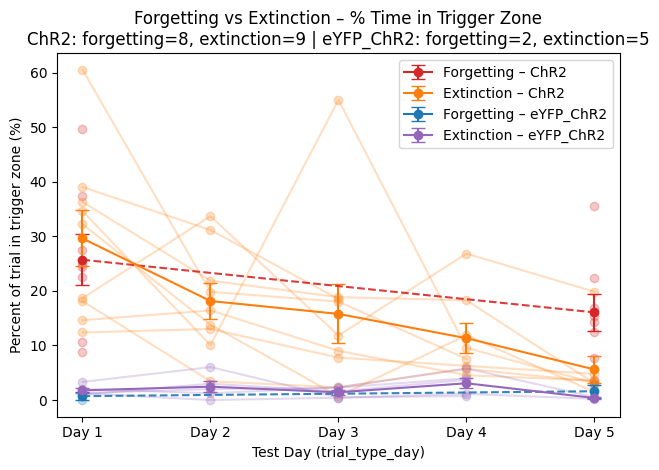

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Restrict to TEST trials, desired genotypes, and NOT short_duration ----
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1)
].copy()

max_day = 5
day_values = np.arange(1, max_day + 1)


def build_subject_matrix(meta_group):
    performance_mat = []
    subjects_used = []

    for sub in meta_group['sub'].unique():
        meta_sub = meta_group[meta_group['sub'] == sub]
        mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
        days_present = np.array(sorted(mean_pct_by_day.index.values))

        # Skip those with only day 1
        if (len(days_present) == 1) and (days_present[0] == 1):
            continue

        subj_vec = np.full(max_day, np.nan)
        for i, day in enumerate(day_values):
            if day in mean_pct_by_day.index:
                subj_vec[i] = mean_pct_by_day.loc[day]

        if np.isnan(subj_vec).all():
            continue

        performance_mat.append(subj_vec)
        subjects_used.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects_used


def mean_and_sem(mat):
    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
    return mean, sem


# ---- 2. Build matrices for genotype × test_type ----
meta_ChR2 = meta_T[meta_T['genotype'] == 'ChR2']
meta_eYFP = meta_T[meta_T['genotype'] == 'eYFP_ChR2']

perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(meta_ChR2[meta_ChR2['test_type'] == 'forgetting'])
perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(meta_ChR2[meta_ChR2['test_type'] == 'extinction'])

perf_f_YFP, subs_f_YFP = build_subject_matrix(meta_eYFP[meta_eYFP['test_type'] == 'forgetting'])
perf_e_YFP, subs_e_YFP = build_subject_matrix(meta_eYFP[meta_eYFP['test_type'] == 'extinction'])


# ---- 3. Plot ----
plt.figure()

# Colors requested:
col_f_ChR2 = 'tab:red'        # less saturated red
col_f_YFP = 'tab:blue'        # blue
col_e_ChR2 = 'tab:orange'     # orange
col_e_YFP = 'tab:purple'      # purple

# Individual traces (faint)
if perf_f_ChR2 is not None:
    for i in range(perf_f_ChR2.shape[0]):
        plt.plot(day_values, perf_f_ChR2[i, :], '-o', color=col_f_ChR2, alpha=0.25, label='_nolegend_')

if perf_e_ChR2 is not None:
    for i in range(perf_e_ChR2.shape[0]):
        plt.plot(day_values, perf_e_ChR2[i, :], '-o', color=col_e_ChR2, alpha=0.25, label='_nolegend_')

if perf_f_YFP is not None:
    for i in range(perf_f_YFP.shape[0]):
        plt.plot(day_values, perf_f_YFP[i, :], '-o', color=col_f_YFP, alpha=0.25, label='_nolegend_')

if perf_e_YFP is not None:
    for i in range(perf_e_YFP.shape[0]):
        plt.plot(day_values, perf_e_YFP[i, :], '-o', color=col_e_YFP, alpha=0.25, label='_nolegend_')


# Group means ± SEM
if perf_f_ChR2 is not None:
    mean, sem = mean_and_sem(perf_f_ChR2)
    plt.errorbar(day_values, mean, yerr=sem, fmt='-o', capsize=5, color=col_f_ChR2, label='Forgetting – ChR2')

if perf_e_ChR2 is not None:
    mean, sem = mean_and_sem(perf_e_ChR2)
    plt.errorbar(day_values, mean, yerr=sem, fmt='-o', capsize=5, color=col_e_ChR2, label='Extinction – ChR2')

if perf_f_YFP is not None:
    mean, sem = mean_and_sem(perf_f_YFP)
    plt.errorbar(day_values, mean, yerr=sem, fmt='-o', capsize=5, color=col_f_YFP, label='Forgetting – eYFP_ChR2')

if perf_e_YFP is not None:
    mean, sem = mean_and_sem(perf_e_YFP)
    plt.errorbar(day_values, mean, yerr=sem, fmt='-o', capsize=5, color=col_e_YFP, label='Extinction – eYFP_ChR2')


# Group forgetting dashed lines Day1 → Day5
# ChR2
if perf_f_ChR2 is not None:
    mean, _ = mean_and_sem(perf_f_ChR2)
    if not np.isnan(mean[0]) and not np.isnan(mean[4]):
        plt.plot([1, 5], [mean[0], mean[4]], '--', color=col_f_ChR2, alpha=0.9)

# eYFP
if perf_f_YFP is not None:
    mean, _ = mean_and_sem(perf_f_YFP)
    if not np.isnan(mean[0]) and not np.isnan(mean[4]):
        plt.plot([1, 5], [mean[0], mean[4]], '--', color=col_f_YFP, alpha=0.9)


# Sample sizes
title_str = (
    "Forgetting vs Extinction – % Time in Trigger Zone\n"
    f"ChR2: forgetting={len(subs_f_ChR2)}, extinction={len(subs_e_ChR2)} | "
    f"eYFP_ChR2: forgetting={len(subs_f_YFP)}, extinction={len(subs_e_YFP)}"
)

plt.title(title_str)
plt.xlabel('Test Day (trial_type_day)')
plt.ylabel('Percent of trial in trigger zone (%)')
plt.xticks(day_values, [f'Day {d}' for d in day_values])
plt.legend()
plt.tight_layout()
plt.show()

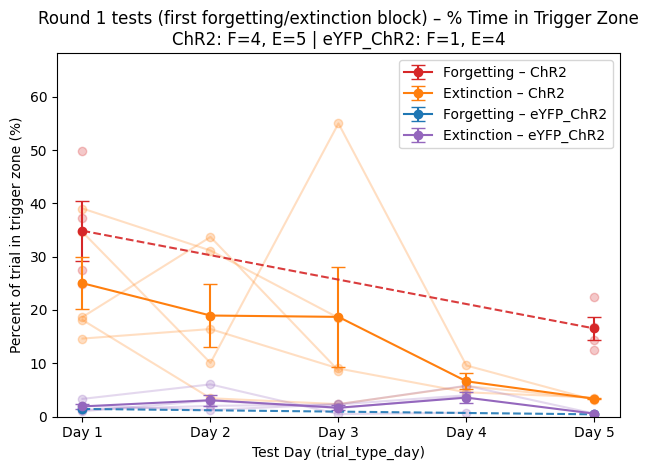

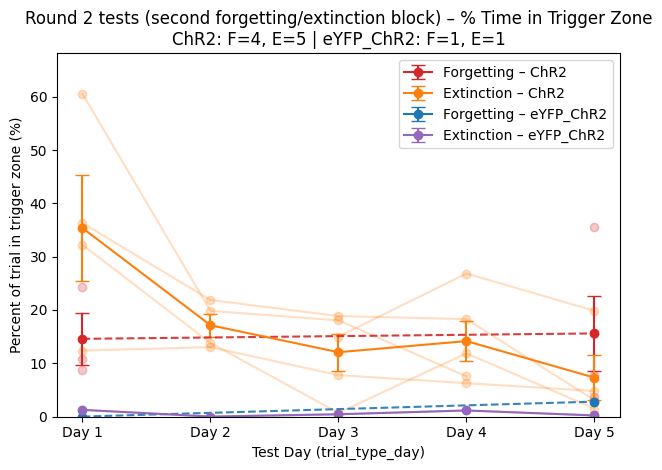

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Filter metadata to test trials & assign test_round from test_order
# ============================================================

# Keep only test trials, the two genotypes, and non-short-duration
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1)
].copy()

# Make sure test_order is string
meta_T['test_order'] = meta_T['test_order'].astype(str)

# Initialise test_round
meta_T['test_round'] = np.nan  # will be 1 or 2

# Rules:
# ef: extinction first, forgetting second
# fe: forgetting first, extinction second
# e:  only extinction → all extinction = round 1
# ee: two extinction rounds → split by day into first half / second half
# ff: two forgetting rounds → same as above
for sub in meta_T['sub'].unique():
    sub_mask = (meta_T['sub'] == sub)
    sub_rows = meta_T[sub_mask].sort_values('trial_type_day')

    if len(sub_rows) == 0:
        continue

    order = sub_rows['test_order'].iloc[0]

    # ef: extinction first, forgetting second
    if order == 'ef':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 1
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'forgetting'), 'test_round'] = 2

    # fe: forgetting first, extinction second
    elif order == 'fe':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'forgetting'), 'test_round'] = 1
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 2

    # e: only extinction → all extinction trials are round 1
    elif order == 'e':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 1

    # ee: two extinction rounds → split by day into first half / second half
    elif order == 'ee':
        e_rows = sub_rows[sub_rows['test_type'] == 'extinction'].sort_values('trial_type_day')
        idx = e_rows.index.to_numpy()
        n = len(idx)
        if n > 0:
            split = int(np.ceil(n / 2))  # first ~half = round 1
            first_half = idx[:split]
            second_half = idx[split:]
            meta_T.loc[first_half, 'test_round'] = 1
            if len(second_half) > 0:
                meta_T.loc[second_half, 'test_round'] = 2

    # ff: two forgetting rounds → split by day into first half / second half
    elif order == 'ff':
        f_rows = sub_rows[sub_rows['test_type'] == 'forgetting'].sort_values('trial_type_day')
        idx = f_rows.index.to_numpy()
        n = len(idx)
        if n > 0:
            split = int(np.ceil(n / 2))
            first_half = idx[:split]
            second_half = idx[split:]
            meta_T.loc[first_half, 'test_round'] = 1
            if len(second_half) > 0:
                meta_T.loc[second_half, 'test_round'] = 2

    # else: unknown test_order → leave as NaN (ignored later)

max_day = 5
day_values = np.arange(1, max_day + 1)  # [1..5]


# ============================================================
# 2. Helper functions
# ============================================================

def build_subject_matrix(meta_group):
    """
    For a given subset (e.g. ChR2 + forgetting + round1),
    return:
      - performance_mat: (n_subjects x max_day) array with NaNs for missing days
      - subjects_used: list of subject IDs included

    Skips subjects that only have day 1 in this subset.
    """
    performance_mat = []
    subjects_used = []

    for sub in meta_group['sub'].unique():
        meta_sub = meta_group[meta_group['sub'] == sub]

        if len(meta_sub) == 0:
            continue

        # Mean % time in trigger zone per test day for this subject
        mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
        days_present = np.array(sorted(mean_pct_by_day.index.values))

        # Exclude subjects with only day 1 in this condition
        if (len(days_present) == 1) and (days_present[0] == 1):
            continue

        subj_vec = np.full(max_day, np.nan)
        for i, day in enumerate(day_values):
            if day in mean_pct_by_day.index:
                subj_vec[i] = mean_pct_by_day.loc[day]

        if np.isnan(subj_vec).all():
            continue

        performance_mat.append(subj_vec)
        subjects_used.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects_used


def mean_and_sem(mat):
    """Mean ± SEM across subjects, per day, handling all-NaN columns."""
    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
    return mean, sem


def plot_round(meta_T_full, round_num, title_prefix, y_limits=None):
    """Make a plot for test round 1 or 2."""
    meta_round = meta_T_full[meta_T_full['test_round'] == round_num].copy()
    if len(meta_round) == 0:
        print(f'No data for test_round {round_num}')
        return

    # split by genotype
    meta_ChR2 = meta_round[meta_round['genotype'] == 'ChR2']
    meta_eYFP = meta_round[meta_round['genotype'] == 'eYFP_ChR2']

    # build matrices for genotype × test_type
    perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(
        meta_ChR2[meta_ChR2['test_type'] == 'forgetting'])
    perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(
        meta_ChR2[meta_ChR2['test_type'] == 'extinction'])

    perf_f_YFP, subs_f_YFP = build_subject_matrix(
        meta_eYFP[meta_eYFP['test_type'] == 'forgetting'])
    perf_e_YFP, subs_e_YFP = build_subject_matrix(
        meta_eYFP[meta_eYFP['test_type'] == 'extinction'])

    # colors
    col_f_ChR2 = 'tab:red'       # soft red
    col_f_YFP = 'tab:blue'       # blue
    col_e_ChR2 = 'tab:orange'    # orange
    col_e_YFP = 'tab:purple'     # purple

    plt.figure()

    # ----- individual traces -----
    if perf_f_ChR2 is not None:
        for i in range(perf_f_ChR2.shape[0]):
            plt.plot(day_values, perf_f_ChR2[i, :],
                     '-o', color=col_f_ChR2, alpha=0.25, label='_nolegend_')

    if perf_e_ChR2 is not None:
        for i in range(perf_e_ChR2.shape[0]):
            plt.plot(day_values, perf_e_ChR2[i, :],
                     '-o', color=col_e_ChR2, alpha=0.25, label='_nolegend_')

    if perf_f_YFP is not None:
        for i in range(perf_f_YFP.shape[0]):
            plt.plot(day_values, perf_f_YFP[i, :],
                     '-o', color=col_f_YFP, alpha=0.25, label='_nolegend_')

    if perf_e_YFP is not None:
        for i in range(perf_e_YFP.shape[0]):
            plt.plot(day_values, perf_e_YFP[i, :],
                     '-o', color=col_e_YFP, alpha=0.25, label='_nolegend_')

    # ----- group means ± SEM -----
    mean_f_ChR2 = mean_f_YFP = None

    if perf_f_ChR2 is not None:
        mean_f_ChR2, sem = mean_and_sem(perf_f_ChR2)
        plt.errorbar(day_values, mean_f_ChR2, yerr=sem,
                     fmt='-o', color=col_f_ChR2, capsize=5,
                     label='Forgetting – ChR2')

    if perf_e_ChR2 is not None:
        mean, sem = mean_and_sem(perf_e_ChR2)
        plt.errorbar(day_values, mean, yerr=sem,
                     fmt='-o', color=col_e_ChR2, capsize=5,
                     label='Extinction – ChR2')

    if perf_f_YFP is not None:
        mean_f_YFP, sem = mean_and_sem(perf_f_YFP)
        plt.errorbar(day_values, mean_f_YFP, yerr=sem,
                     fmt='-o', color=col_f_YFP, capsize=5,
                     label='Forgetting – eYFP_ChR2')

    if perf_e_YFP is not None:
        mean, sem = mean_and_sem(perf_e_YFP)
        plt.errorbar(day_values, mean, yerr=sem,
                     fmt='-o', color=col_e_YFP, capsize=5,
                     label='Extinction – eYFP_ChR2')

    # dashed Day1–Day5 for forgetting group means (ChR2 & eYFP)
    if mean_f_ChR2 is not None and not np.isnan(mean_f_ChR2[0]) and not np.isnan(mean_f_ChR2[4]):
        plt.plot([1, 5], [mean_f_ChR2[0], mean_f_ChR2[4]],
                 '--', color=col_f_ChR2, alpha=0.9)

    if mean_f_YFP is not None and not np.isnan(mean_f_YFP[0]) and not np.isnan(mean_f_YFP[4]):
        plt.plot([1, 5], [mean_f_YFP[0], mean_f_YFP[4]],
                 '--', color=col_f_YFP, alpha=0.9)

    # sample sizes
    n_f_ChR2 = len(subs_f_ChR2)
    n_e_ChR2 = len(subs_e_ChR2)
    n_f_YFP = len(subs_f_YFP)
    n_e_YFP = len(subs_e_YFP)

    title_str = (
        f'{title_prefix} – % Time in Trigger Zone\n'
        f'ChR2: F={n_f_ChR2}, E={n_e_ChR2} | '
        f'eYFP_ChR2: F={n_f_YFP}, E={n_e_YFP}'
    )

    plt.title(title_str)
    plt.xlabel('Test Day (trial_type_day)')
    plt.ylabel('Percent of trial in trigger zone (%)')
    plt.xticks(day_values, [f'Day {d}' for d in day_values])
    plt.legend()

    # apply shared y-limits if provided
    if y_limits is not None:
        plt.ylim(y_limits)

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Compute shared y-axis limits across ALL test trials
# ============================================================

valid_vals = meta_T['pct_time_in_trigger'].values
valid_vals = valid_vals[~np.isnan(valid_vals)]

if len(valid_vals) > 0:
    y_min = 0
    y_max = 62
    #y_max = np.nanmax(valid_vals)
    y_limits = (y_min, y_max * 1.1)  # little headroom
else:
    y_limits = None  # fallback


# ============================================================
# 4. Make the two figures: round 1 and round 2 (shared y-axis)
# ============================================================

plot_round(
    meta_T,
    round_num=1,
    title_prefix='Round 1 tests (first forgetting/extinction block)',
    y_limits=y_limits
)

plot_round(
    meta_T,
    round_num=2,
    title_prefix='Round 2 tests (second forgetting/extinction block)',
    y_limits=y_limits
)

In [ ]:

cheeseboardMap = util.load_cheeseboard_map()
metadata = util.load_metadata()

# Create a column for minimum time to well in the metadata
metadata['min_time_to_well'] = np.nan

for idx in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[idx])
    position = dl.get_data('position')
    if position is None:
        continue
    x_loc = position['smooth_trans_x'].values
    y_loc = position['smooth_trans_y'].values
    in_roi = position['inside_roi'].values
    x_loc[x_loc == -1] = np.nan
    y_loc[y_loc == -1] = np.nan



    # Get the trigger locations
    well_coords = []
    for i in range(len(triggerLoc)):
        cheeseboardMap_loc = cheeseboardMap[(cheeseboardMap['well_row'] == triggerLoc['well_row'].values[i]) & (cheeseboardMap['well_col'] == triggerLoc['well_col'].values[i])]
        well_coords.append((cheeseboardMap_loc['trans_X'].values[0], cheeseboardMap_loc['trans_Y'].values[0]))


    well_behav_metrics = compute_well_behav_metrics_all(x_loc, y_loc, well_coords)
    if np.nansum(well_behav_metrics['fraction_time_in_well']) == 0:
        continue
    min_time_to_well = np.nanmin(well_behav_metrics['time_to_arrive_zone'].values)
    metadata.at[idx, 'min_time_to_well'] = min_time_to_well

In [ ]:
metadata_L = metadata[metadata['trial_type'] == 'L']#.reset_index(drop=True)